# V1005 · TensorCCC + CompGraph
Independent outcome-blind experiments; original V1000–V1004 files are read-only. Tables and plots load recorded full-data runs; no algorithms are reimplemented here.

当前 HBC1 与 Prime 5K 的 panel、annotation 和 retained CCC space 差异较大，只做各自独立分析，不做跨切片共享验证。以后使用连续切片或技术条件一致的数据专门评估 cross-slice consistency.

In [1]:
import sys
from pathlib import Path
sys.dont_write_bytecode=True
ROOT=Path('/home/xueshuailin/CCC_Phe/V1005')
sys.path.insert(0,str(ROOT/'src'))
get_ipython().run_line_magic('matplotlib','inline')
from phenoniche.v1005 import reporting as report

## 1. Data loading and QC

In [2]:
report.audit()

,hbc1 input QC
n_cells,166363
n_genes,313
nnz,10604415
nnz_per_cell_median,64.0
zero_cells,0
counts_per_cell_mean,192.969314
nonnegative,True
integer_valued,True


**hbc1 original labels → fixed coarse taxonomy.**

,original_label,n_cells,coarse_type
0,Stromal,41422,Fibroblast
1,Invasive_Tumor,34374,Epithelial
2,DCIS_1,12923,Epithelial
3,DCIS_2,11683,Epithelial
4,Macrophages_1,11174,Macrophage
5,Endothelial,8931,Endothelial
6,CD4+_T_Cells,8453,T cell
7,Unlabeled,7137,Unknown
8,Myoepi_ACTA2+,7078,Myoepithelial
9,CD8+_T_Cells,6940,T cell


,xenium5k input QC
n_cells,699110
n_genes,5101
nnz,58327284
nnz_per_cell_median,46.0
zero_cells,15312
counts_per_cell_mean,102.370628
nonnegative,True
integer_valued,True


**xenium5k original labels → fixed coarse taxonomy.**

,original_label,n_cells,coarse_type
0,Unassigned,172907,Unknown
1,T cell,143795,T cell
2,Epithelial,126326,Epithelial
3,Fibroblast,79988,Fibroblast
4,B cell,57639,B cell
5,Macrophage,57194,Macrophage
6,Endothelial,32096,Endothelial
7,Pericyte,12744,Pericyte
8,Mast cell,8842,Mast cell
9,Myoepithelial,7579,Myoepithelial


,dataset,N,C,L,retained_features,nnz,sparsity,neighbors,sigma,annotation_status
0,hbc1,166363,11,40,1418,23709646,0.899494,30,20.0,official observed labels
1,xenium5k,699110,10,2870,494,18198654,0.947305,30,20.0,existing provisional marker-based annotation; ...


## 2. Cell-type spatial maps

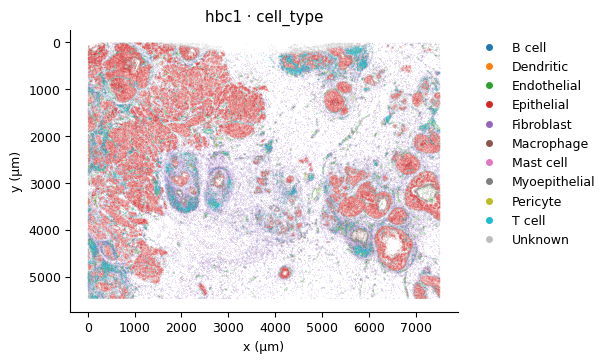

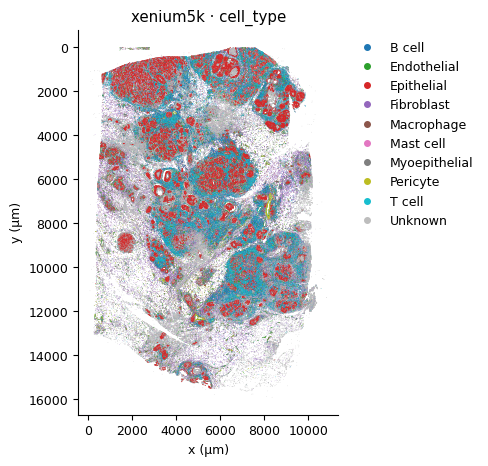

In [3]:
report.spatial('hbc1',cell_types=True)
report.spatial('xenium5k',cell_types=True)

## 3. LR / CCC tensor audit

In [4]:
report.tensor_audit()

**hbc1:** conceptual shape `[166363, 11, 11, 40]`; retained `1,418` directed entries per anchor; sparse zero fraction `0.899`. No Top-N input selection.

,sender_id,receiver_id,lr_index,sender,receiver,ligand,receptor,lr_id
0,0,0,4,B cell,B cell,CD69,KLRB1,CommuSpace_HS_01204
1,0,0,9,B cell,B cell,CDH1,CDH1,CommuSpace_HS_01239
2,0,0,11,B cell,B cell,CEACAM6,CEACAM6,CommuSpace_HS_01291
3,0,0,16,B cell,B cell,CXCL12,CD4,CommuSpace_HS_02207
4,0,0,17,B cell,B cell,CXCL12,CXCR4,CommuSpace_HS_02209
5,0,0,22,B cell,B cell,MMP2,PECAM1,CommuSpace_HS_05481
6,0,0,25,B cell,B cell,MRC1,PTPRC,CommuSpace_HS_05529
7,0,0,29,B cell,B cell,PECAM1,PECAM1,CommuSpace_HS_06139
8,0,0,32,B cell,B cell,PTPRC,CD4,CommuSpace_HS_06469
9,0,0,33,B cell,B cell,PTPRC,MRC1,CommuSpace_HS_06471


,coverage,pair_support_fraction,pair_support_min,dense_tensor_bytes_avoided
0,0.1,0.01,20,3220787680


**xenium5k:** conceptual shape `[699110, 10, 10, 2870]`; retained `494` directed entries per anchor; sparse zero fraction `0.947`. No Top-N input selection.

,sender_id,receiver_id,lr_index,sender,receiver,ligand,receptor,lr_id
0,1,1,131,Endothelial,Endothelial,APP,FLT1,CommuSpace_HS_00391
1,1,1,404,Endothelial,Endothelial,CCN1,ITGB3,CommuSpace_HS_01082
2,1,1,585,Endothelial,Endothelial,COL4A1,CD93,CommuSpace_HS_01731
3,1,1,593,Endothelial,Endothelial,COL4A2,CD93,CommuSpace_HS_01751
4,1,1,599,Endothelial,Endothelial,COL4A2,ITGB3,CommuSpace_HS_01767
5,1,1,890,Endothelial,Endothelial,ENG,BMPR2,CommuSpace_HS_02648
6,1,1,2068,Endothelial,Endothelial,PECAM1,ITGB3,CommuSpace_HS_06138
7,1,1,2069,Endothelial,Endothelial,PECAM1,PECAM1,CommuSpace_HS_06139
8,1,1,2206,Endothelial,Endothelial,PTPRM,PTPRM,CommuSpace_HS_06474
9,1,1,2505,Endothelial,Endothelial,THBS1,ITGB3,CommuSpace_HS_07380


,coverage,pair_support_fraction,pair_support_min,dense_tensor_bytes_avoided
0,0.1,0.01,20,802578280000


## 4. Tensor shape, sparsity and fixed filters

In [5]:
report.tensor_audit()

**hbc1:** conceptual shape `[166363, 11, 11, 40]`; retained `1,418` directed entries per anchor; sparse zero fraction `0.899`. No Top-N input selection.

,sender_id,receiver_id,lr_index,sender,receiver,ligand,receptor,lr_id
0,0,0,4,B cell,B cell,CD69,KLRB1,CommuSpace_HS_01204
1,0,0,9,B cell,B cell,CDH1,CDH1,CommuSpace_HS_01239
2,0,0,11,B cell,B cell,CEACAM6,CEACAM6,CommuSpace_HS_01291
3,0,0,16,B cell,B cell,CXCL12,CD4,CommuSpace_HS_02207
4,0,0,17,B cell,B cell,CXCL12,CXCR4,CommuSpace_HS_02209
5,0,0,22,B cell,B cell,MMP2,PECAM1,CommuSpace_HS_05481
6,0,0,25,B cell,B cell,MRC1,PTPRC,CommuSpace_HS_05529
7,0,0,29,B cell,B cell,PECAM1,PECAM1,CommuSpace_HS_06139
8,0,0,32,B cell,B cell,PTPRC,CD4,CommuSpace_HS_06469
9,0,0,33,B cell,B cell,PTPRC,MRC1,CommuSpace_HS_06471


,coverage,pair_support_fraction,pair_support_min,dense_tensor_bytes_avoided
0,0.1,0.01,20,3220787680


**xenium5k:** conceptual shape `[699110, 10, 10, 2870]`; retained `494` directed entries per anchor; sparse zero fraction `0.947`. No Top-N input selection.

,sender_id,receiver_id,lr_index,sender,receiver,ligand,receptor,lr_id
0,1,1,131,Endothelial,Endothelial,APP,FLT1,CommuSpace_HS_00391
1,1,1,404,Endothelial,Endothelial,CCN1,ITGB3,CommuSpace_HS_01082
2,1,1,585,Endothelial,Endothelial,COL4A1,CD93,CommuSpace_HS_01731
3,1,1,593,Endothelial,Endothelial,COL4A2,CD93,CommuSpace_HS_01751
4,1,1,599,Endothelial,Endothelial,COL4A2,ITGB3,CommuSpace_HS_01767
5,1,1,890,Endothelial,Endothelial,ENG,BMPR2,CommuSpace_HS_02648
6,1,1,2068,Endothelial,Endothelial,PECAM1,ITGB3,CommuSpace_HS_06138
7,1,1,2069,Endothelial,Endothelial,PECAM1,PECAM1,CommuSpace_HS_06139
8,1,1,2206,Endothelial,Endothelial,PTPRM,PTPRM,CommuSpace_HS_06474
9,1,1,2505,Endothelial,Endothelial,THBS1,ITGB3,CommuSpace_HS_07380


,coverage,pair_support_fraction,pair_support_min,dense_tensor_bytes_avoided
0,0.1,0.01,20,802578280000


## 5. Model structure and frozen parameters

In [6]:
report.config()

Directed tensor → sender/receiver/LR mode projections → LayerNorm/MLP/Softmax → simplex Z. Decoder: H normalized to sum one on every decode. Fixed observed row mass retains CCC intensity; no learned scale. Low-rank penalty is disabled. Composition NMF is independent; fusion acts only on normalized graphs.

**hbc1 frozen configuration**

,value
seed,40700
seeds,"[40700, 40701, 40702, 40703, 40704]"
K,16
Kc,8
warmup_epochs,15
graph_epochs,25
graph_ramp_epochs,10
patience,6
early_stop_min_delta,0.00001
training_revision,simplex_staged


**xenium5k frozen configuration**

,value
seed,40700
seeds,"[40700, 40701, 40702, 40703, 40704]"
K,16
Kc,8
warmup_epochs,15
graph_epochs,25
graph_ramp_epochs,10
patience,6
early_stop_min_delta,0.00001
training_revision,simplex_staged


## 6. HBC1 training results

method,seed,n_niches,median_niche_size,min_niche_size,fraction_cells_niches_lt20,graph_connected_components,mean_degree,degree_min,degree_q25,degree_median,degree_q75,degree_q95,degree_max,spatial_agreement,heldout_MSE,heldout_MAE,heldout_Huber,heldout_entries,H_fraction_below_1pct_row_max,largest_niche_fraction
Composition-only,40700,262,46.0,19,0.000114,203,19.060548,14.0,16.0,18.0,20.0,25.0,66.0,0.336212,NaN,NaN,NaN,NaN,NaN,0.061222
CCC-flat,40700,37,3596.0,21,0.000000,2,21.317865,15.0,18.0,20.0,24.0,31.0,64.0,0.473941,0.168943,0.124273,0.049389,72837.0,NaN,0.071019
CCC-autoencoder-no-prior,40700,60,2433.5,20,0.000000,1,19.629244,15.0,17.0,19.0,22.0,26.0,75.0,0.368790,0.206558,0.110021,0.049067,72837.0,0.708921,0.048809
CCC-tensor,40700,65,2039.0,16,0.000096,4,19.761377,12.0,17.0,19.0,22.0,27.0,54.0,0.375283,0.245670,0.108928,0.050175,72837.0,0.880025,0.060530
Proposed,40700,29,6220.0,61,0.000000,1,38.515199,23.0,35.0,38.0,41.0,48.0,90.0,0.468673,0.245670,0.108928,0.050175,72837.0,0.880025,0.081539
Composition-only,40701,66,557.0,24,0.000000,9,18.853291,14.0,17.0,18.0,21.0,24.0,40.0,0.387173,NaN,NaN,NaN,NaN,NaN,0.083420
CCC-flat,40701,37,4047.0,21,0.000000,2,21.317865,15.0,18.0,20.0,24.0,31.0,64.0,0.470759,0.168943,0.124273,0.049389,72837.0,NaN,0.080102
CCC-autoencoder-no-prior,40701,66,2024.5,25,0.000000,1,19.656222,15.0,17.0,19.0,22.0,27.0,70.0,0.382235,0.277736,0.108597,0.050081,72837.0,0.897435,0.064407
CCC-tensor,40701,61,2043.0,64,0.000000,1,19.693213,12.0,17.0,19.0,22.0,27.0,72.0,0.382160,0.417125,0.110775,0.051722,72837.0,0.901931,0.064395
Proposed,40701,23,6801.0,82,0.000000,1,38.249911,24.0,35.0,38.0,41.0,47.0,108.0,0.503283,0.417125,0.110775,0.051722,72837.0,0.901931,0.086852


model,Z_entropy,effective_active_programs,mean_per_cell_effective_programs,singular_max,singular_min,near_constant_fraction,Z_variance_1,Z_variance_2,Z_variance_3,Z_variance_4,Z_variance_5,Z_variance_6,Z_variance_7,Z_variance_8,Z_variance_9,Z_variance_10,Z_variance_11,Z_variance_12,Z_variance_13,Z_variance_14,Z_variance_15,Z_variance_16,H_row_sum_max_error,Z_row_sum_max_error,H_other_program_cosine_median,H_other_program_cosine_max,centered_Z_first_component_variance_fraction,centered_Z_effective_rank,maximum_latent_column_std,H_fraction_below_1pct_row_max
seed_40700_no_prior,1.262950,12.272432,3.953432,19.791672,0.000043,0.1250,0.014551,0.011694,0.009464,0.012850,0.015339,1.911912e-12,4.790882e-13,0.050931,0.030997,0.034266,0.015434,0.001640,0.020593,0.010087,0.017879,0.053353,1.788139e-07,2.337826e-07,0.071944,0.949197,0.237988,11.942134,0.228444,0.708921
seed_40700_tensor,1.372860,13.922184,4.482683,18.400343,0.000005,0.0625,0.012152,0.012372,0.009236,0.010358,0.010408,8.800475e-03,5.485631e-15,0.045408,0.021355,0.018509,0.013414,0.019859,0.018525,0.010005,0.017049,0.049395,1.192093e-07,2.166356e-07,0.019957,0.312339,0.228335,13.204699,0.221420,0.880025
seed_40701_no_prior,1.360539,13.692370,4.403426,19.165659,4.728180,0.0000,0.020433,0.008431,0.007313,0.009978,0.010150,9.455138e-03,1.059466e-02,0.024383,0.017810,0.021738,0.013809,0.009188,0.006240,0.010935,0.045657,0.040285,1.192093e-07,2.450878e-07,0.012233,0.448211,0.209141,14.134882,0.208651,0.897435
seed_40701_tensor,1.378025,13.262437,4.434927,19.986046,4.213899,0.0000,0.023216,0.006321,0.005750,0.007742,0.010116,7.976882e-03,2.520980e-02,0.024033,0.018284,0.021463,0.015030,0.007096,0.004944,0.009381,0.025641,0.038477,1.788139e-07,2.217491e-07,0.006049,0.416859,0.192444,14.062922,0.187933,0.901931
seed_40702_no_prior,1.315568,13.349117,4.170873,18.921562,0.104744,0.0000,0.008592,0.020829,0.019910,0.027703,0.041158,7.723433e-03,2.832819e-06,0.009182,0.013290,0.009099,0.012318,0.016637,0.030088,0.027463,0.027265,0.010905,1.192093e-07,2.339321e-07,0.022411,0.954710,0.186704,13.404761,0.194432,0.835596
seed_40702_tensor,1.376377,13.804046,4.420833,19.042131,4.593634,0.0000,0.005438,0.018909,0.020055,0.025709,0.037663,6.950964e-03,1.171838e-02,0.010584,0.010436,0.009133,0.010073,0.013523,0.021901,0.024757,0.023937,0.009411,1.192093e-07,2.062988e-07,0.010713,0.337463,0.183563,14.259872,0.187077,0.902327
seed_40703_no_prior,1.331866,13.752646,4.361262,19.103735,3.557228,0.0000,0.024201,0.048225,0.009124,0.023954,0.009128,4.928247e-02,8.322159e-03,0.023233,0.012013,0.003805,0.008005,0.012785,0.027245,0.010089,0.009536,0.007104,1.192093e-07,2.322047e-07,0.016081,0.350287,0.218982,13.842613,0.219991,0.891837
seed_40703_tensor,1.331866,13.752646,4.361262,19.103735,3.557228,0.0000,0.024201,0.048225,0.009124,0.023954,0.009128,4.928247e-02,8.322159e-03,0.023233,0.012013,0.003805,0.008005,0.012785,0.027245,0.010089,0.009536,0.007104,1.192093e-07,2.322047e-07,0.016081,0.350287,0.218982,13.842613,0.219991,0.891837
seed_40704_no_prior,1.366120,14.344172,4.469875,18.436580,4.908583,0.0000,0.008975,0.021392,0.050601,0.011771,0.008416,1.072102e-02,8.863862e-03,0.033474,0.014514,0.012325,0.010038,0.040571,0.007210,0.019843,0.007374,0.016949,1.788139e-07,2.205055e-07,0.016323,0.351408,0.221198,14.080731,0.223270,0.882052
seed_40704_tensor,1.362583,14.331575,4.440939,18.407017,4.865373,0.0000,0.010717,0.021553,0.047451,0.010972,0.008368,1.154296e-02,8.574139e-03,0.034192,0.013867,0.013292,0.008993,0.042535,0.007140,0.019867,0.007494,0.016321,1.192093e-07,2.287755e-07,0.016282,0.352331,0.215483,14.091820,0.215630,0.882273


,model,best_epoch,epochs_run,best_validation,lowrank_enabled,prior,warmup_reused,best_graph_weight
0,seed_40700_no_prior_training,11,25,1.757111,False,False,False,0.000
1,seed_40700_tensor_training,16,25,1.754529,False,True,True,0.001
2,seed_40701_no_prior_training,18,25,1.711681,False,False,False,0.000
3,seed_40701_tensor_training,23,29,1.731268,False,True,True,0.008
4,seed_40702_no_prior_training,14,25,1.732116,False,False,False,0.000
5,seed_40702_tensor_training,19,25,1.723473,False,True,True,0.004
6,seed_40703_no_prior_training,14,25,1.737432,False,False,False,0.000
7,seed_40703_tensor_training,14,25,1.737432,False,True,True,0.000
8,seed_40704_no_prior_training,17,25,1.702292,False,False,False,0.000
9,seed_40704_tensor_training,17,25,1.698992,False,True,True,0.002


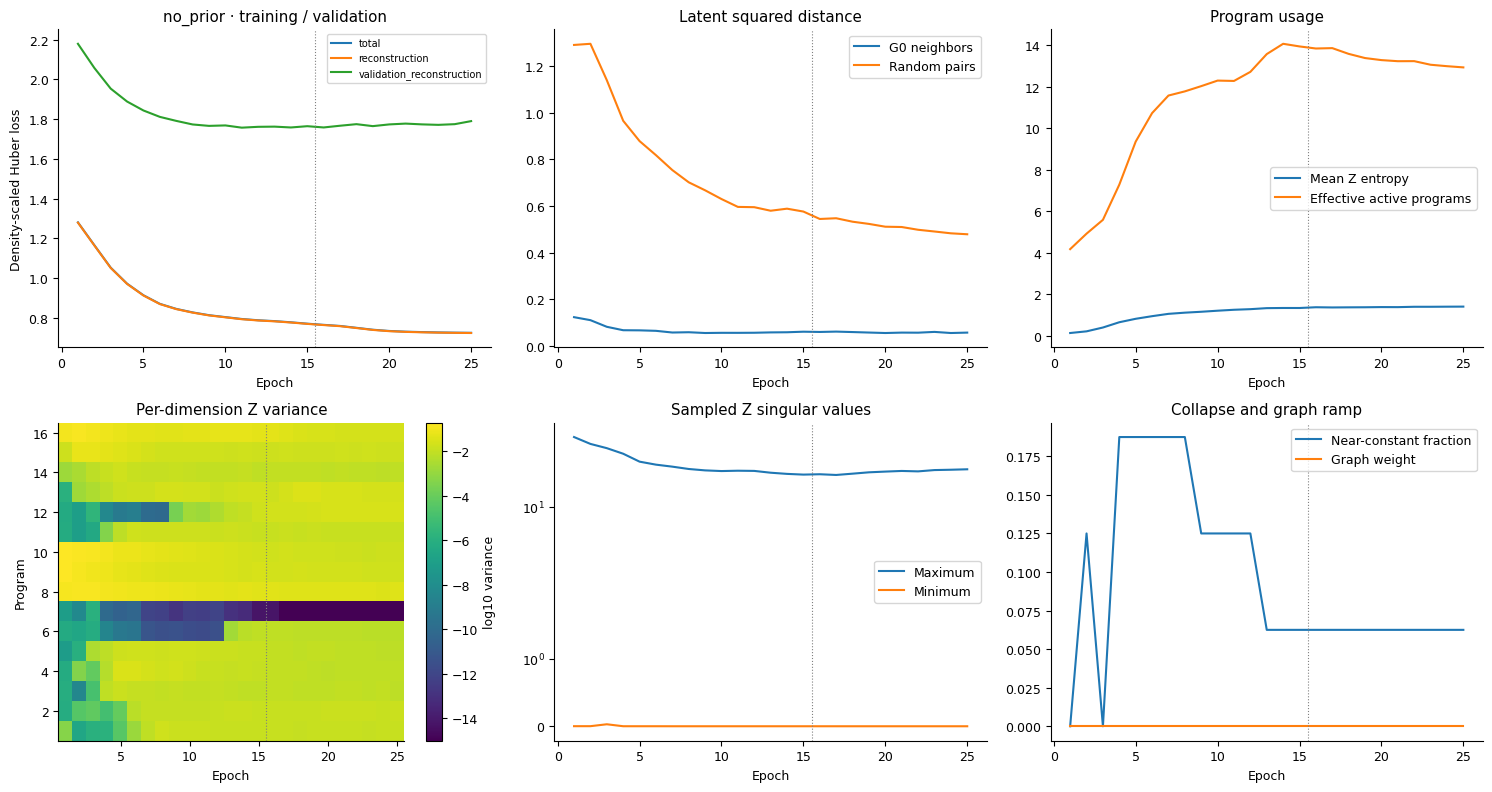

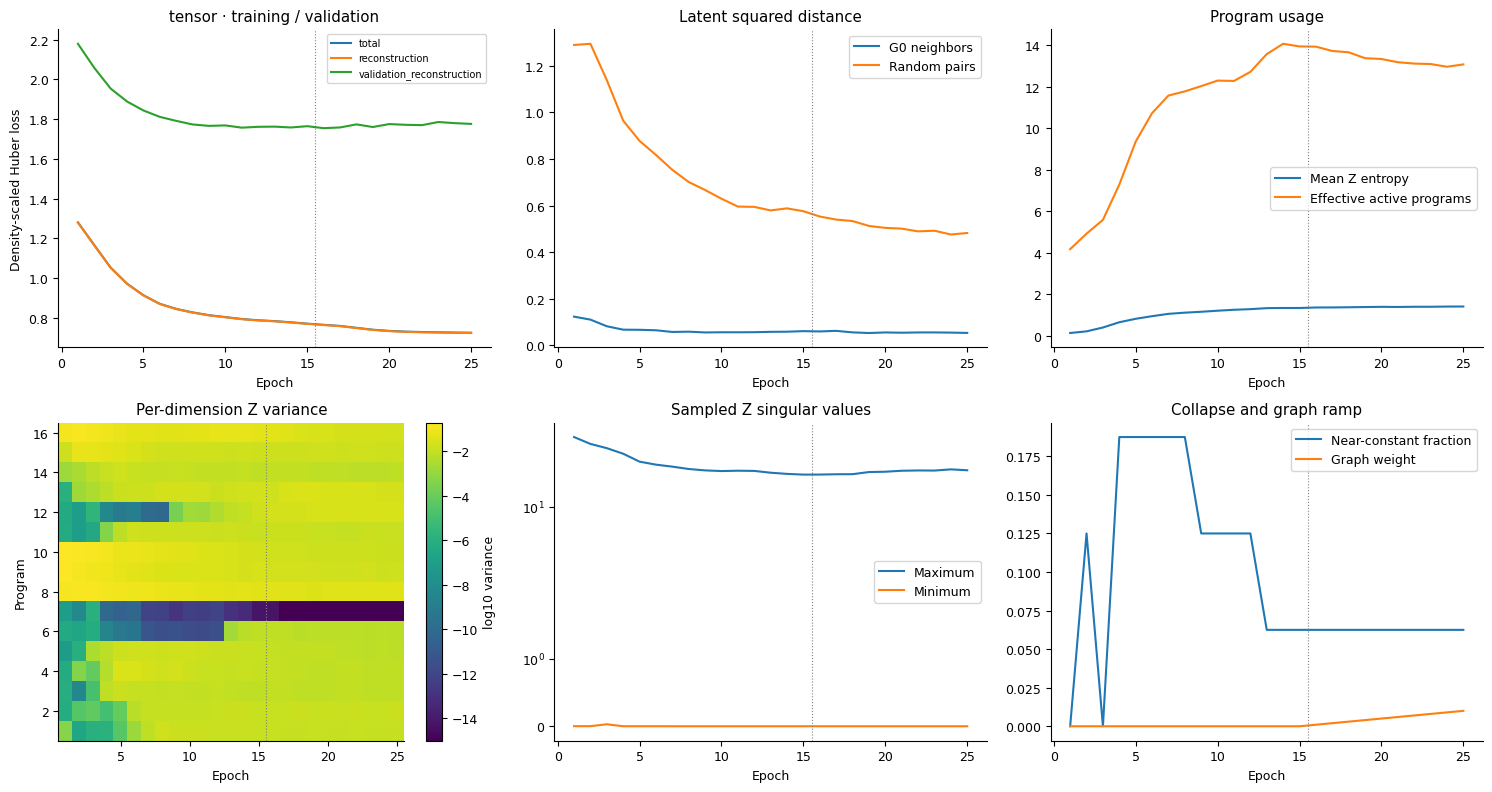

Near-constant means variance < 1e-8 on the fixed 4,096-anchor audit sample. Validation chooses the best checkpoint; separate test entries are never used for early stopping.

In [7]:
report.training('hbc1')

## 7. HBC1 historical spatial niches

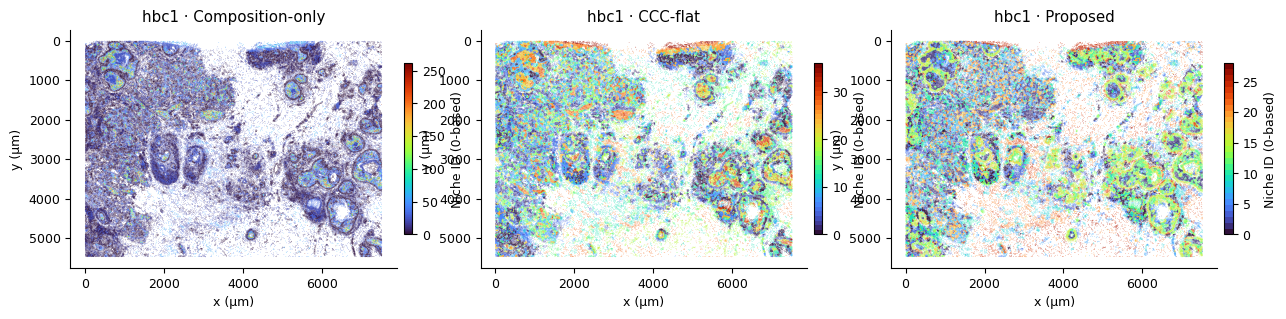

/home/xueshuailin/miniconda3/envs/cccphe/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


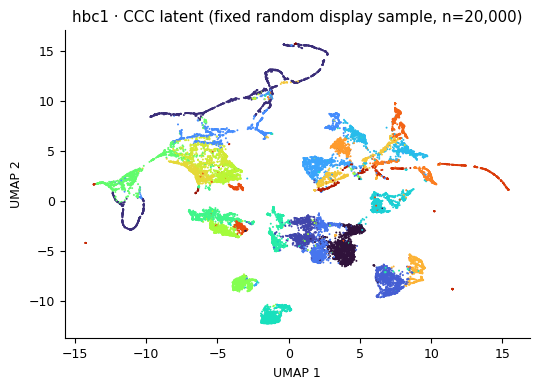

In [8]:
report.spatial('hbc1')
report.latent_map('hbc1')

## 8. HBC1 CCC programs

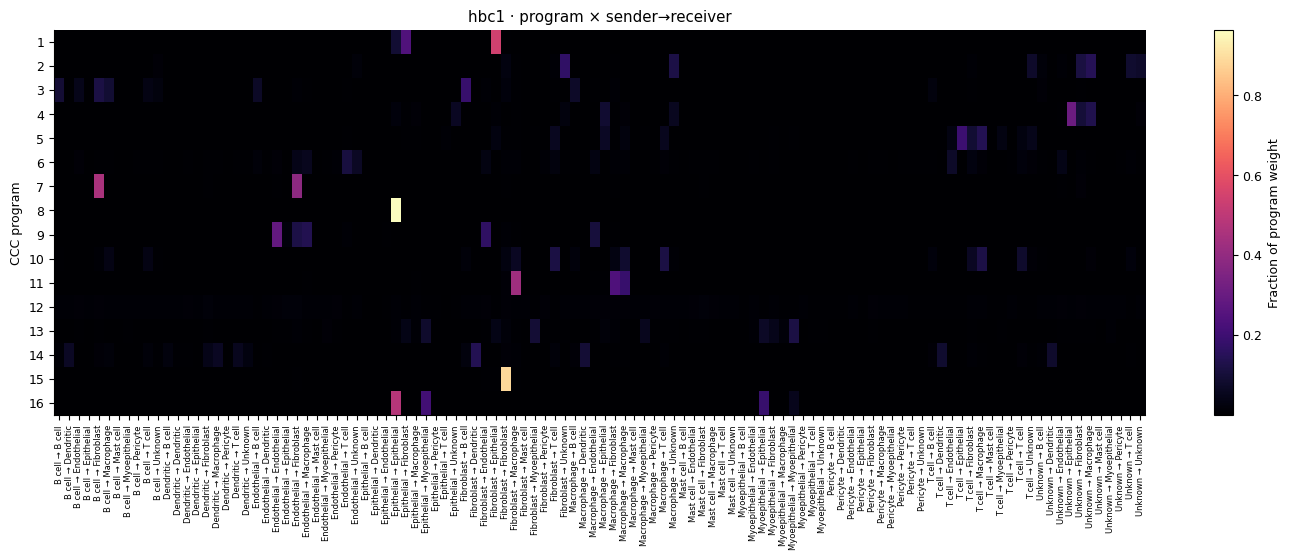

program,entropy,effective_features,fraction_below_1pct_max,weight_sum,top_sender,top_sender_weight,top_receiver,top_receiver_weight,top_pair,top_pair_weight,top_LR,top_LR_weight
1,2.991213,19.909811,0.990127,1.0,Fibroblast,0.563896,Epithelial,0.647561,"('Fibroblast', 'Epithelial')",0.543847,"('CDH1', 'CDH1')",0.414127
2,4.759622,116.701767,0.925247,1.0,Unknown,0.456703,Unknown,0.481035,"('Fibroblast', 'Unknown')",0.171722,"('CXCL12', 'CXCR4')",0.254410
3,5.050135,156.043472,0.909027,1.0,B cell,0.428176,B cell,0.472035,"('Fibroblast', 'B cell')",0.185723,"('CXCL12', 'CXCR4')",0.269346
4,3.849950,46.990704,0.983075,1.0,Unknown,0.568225,Epithelial,0.435454,"('Unknown', 'Epithelial')",0.305309,"('S100A4', 'ERBB2')",0.585677
5,4.226903,68.504738,0.976728,1.0,T cell,0.580024,Epithelial,0.306648,"('T cell', 'Epithelial')",0.199001,"('S100A4', 'ERBB2')",0.605242
6,6.138246,463.240143,0.796192,1.0,Endothelial,0.329455,Endothelial,0.228813,"('Endothelial', 'T cell')",0.109982,"('CXCL12', 'CXCR4')",0.196081
7,4.593987,98.887901,0.951340,1.0,B cell,0.466947,Fibroblast,0.875809,"('B cell', 'Fibroblast')",0.452436,"('MRC1', 'PTPRC')",0.062134
8,0.843888,2.325391,0.997884,1.0,Epithelial,0.965886,Epithelial,0.968049,"('Epithelial', 'Epithelial')",0.963113,"('CDH1', 'CDH1')",0.875381
9,4.327227,75.733955,0.970381,1.0,Endothelial,0.589343,Endothelial,0.583891,"('Endothelial', 'Endothelial')",0.287225,"('PECAM1', 'PECAM1')",0.271545
10,4.893045,133.359100,0.909732,1.0,T cell,0.306485,T cell,0.383911,"('T cell', 'Macrophage')",0.122265,"('CXCL12', 'CXCR4')",0.258116


program,rank,sender_id,receiver_id,lr_index,sender,receiver,ligand,receptor,lr_id,weight
1,1,4,3,35,Fibroblast,Epithelial,S100A4,ERBB2,CommuSpace_HS_06644,0.266576
1,2,4,3,9,Fibroblast,Epithelial,CDH1,CDH1,CommuSpace_HS_01239,0.162925
1,3,3,4,9,Epithelial,Fibroblast,CDH1,CDH1,CommuSpace_HS_01239,0.161142
1,4,3,3,9,Epithelial,Epithelial,CDH1,CDH1,CommuSpace_HS_01239,0.078668
1,5,3,4,10,Epithelial,Fibroblast,CDH1,EGFR,CommuSpace_HS_01241,0.064467
1,6,4,3,17,Fibroblast,Epithelial,CXCL12,CXCR4,CommuSpace_HS_02209,0.054185
1,7,4,3,18,Fibroblast,Epithelial,CXCL12,SDC4,CommuSpace_HS_02218,0.036628
1,8,4,3,21,Fibroblast,Epithelial,MMP2,EGFR,CommuSpace_HS_05474,0.009146
1,9,3,4,13,Epithelial,Fibroblast,CEACAM6,EGFR,CommuSpace_HS_01294,0.008660
1,10,4,3,10,Fibroblast,Epithelial,CDH1,EGFR,CommuSpace_HS_01241,0.006853


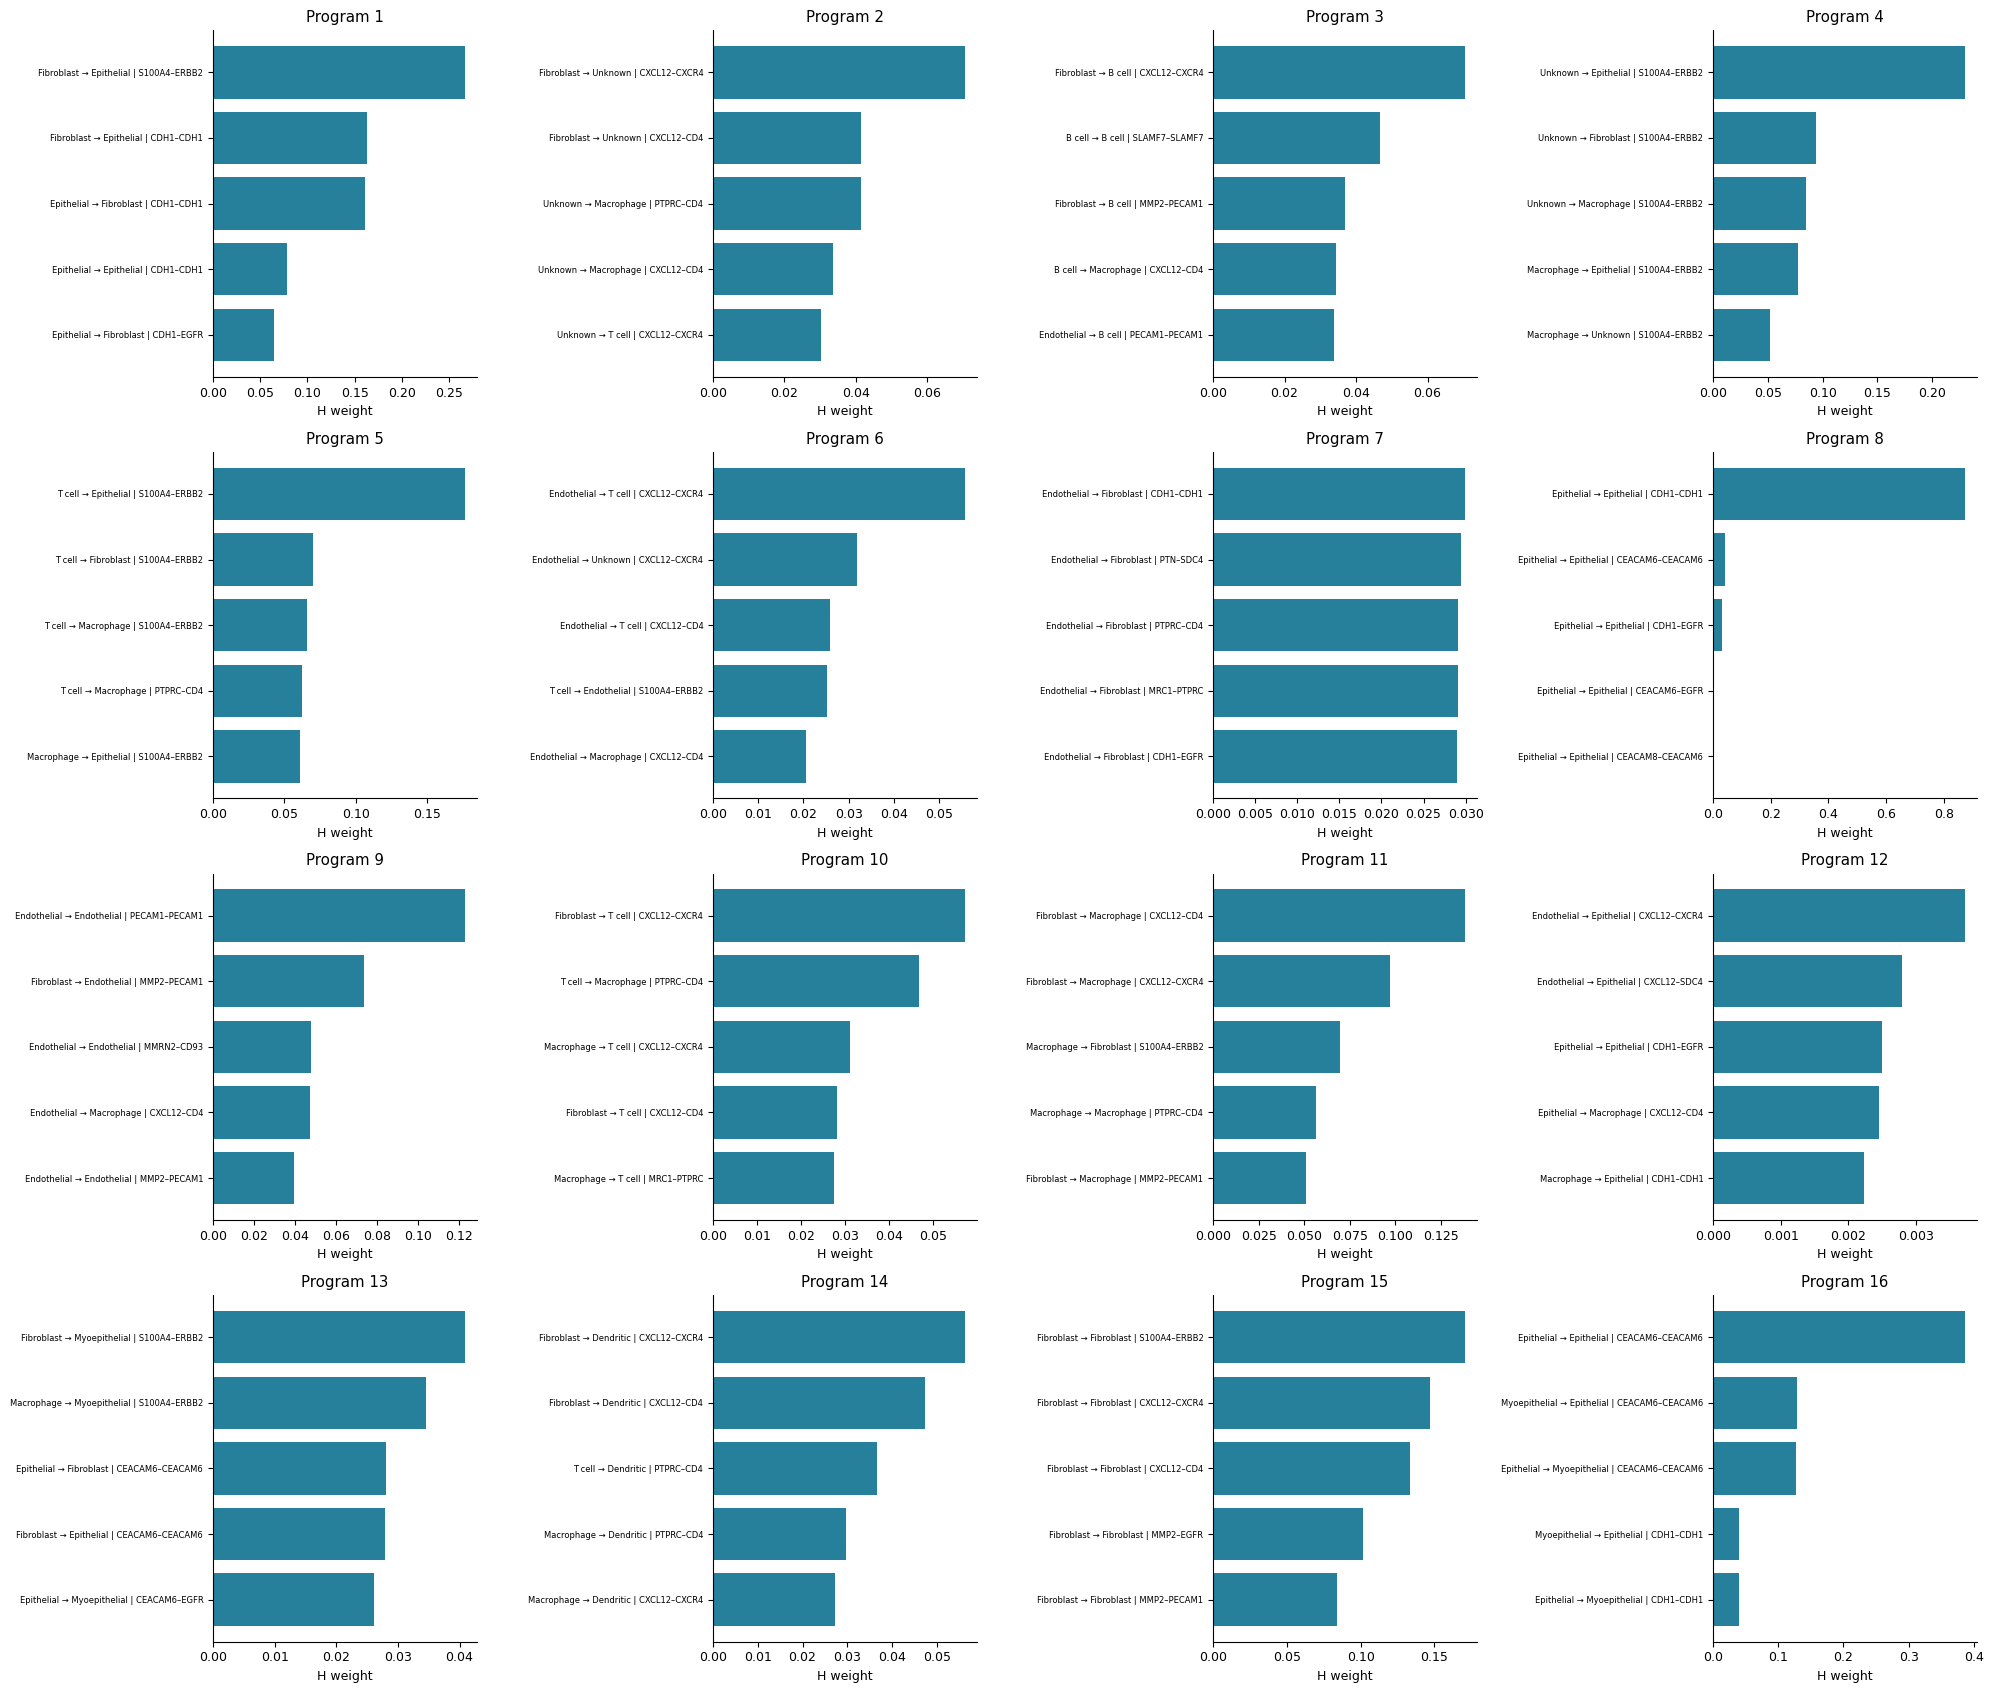

**niche_composition**

niche,B cell,Dendritic,Endothelial,Epithelial,Fibroblast,Macrophage,Mast cell,Myoepithelial,Pericyte,T cell,Unknown
0,0.099468,0.000982,0.121731,0.043028,0.334744,0.131012,0.002403,0.005498,0.013022,0.191415,0.056697
1,0.000040,0.000005,0.000327,0.972999,0.000913,0.005631,0.000000,0.002289,0.000067,0.000390,0.017341
2,0.006003,0.001099,0.120415,0.418172,0.184307,0.096465,0.000928,0.005964,0.009085,0.106307,0.051252
3,0.105134,0.001913,0.001242,0.004929,0.361458,0.145283,0.002230,0.006282,0.001279,0.285823,0.084428
4,0.021769,0.004035,0.161048,0.030089,0.318057,0.116985,0.001704,0.008259,0.017563,0.262175,0.058318
5,0.000788,0.000144,0.002342,0.832761,0.005762,0.048458,0.000092,0.012832,0.000177,0.001896,0.094747
6,0.000886,0.000527,0.139660,0.389987,0.348405,0.080694,0.000745,0.002228,0.017078,0.002176,0.017612
7,0.001370,0.000154,0.004340,0.757600,0.133199,0.061783,0.000401,0.001175,0.000298,0.002361,0.037318
8,0.072264,0.001831,0.083849,0.125124,0.588158,0.074303,0.002052,0.005106,0.008012,0.008181,0.031119
9,0.110732,0.055035,0.001564,0.016134,0.249544,0.134515,0.001406,0.002334,0.001431,0.363743,0.063561


**niche_program_activity**

niche,Program 1,Program 2,Program 3,Program 4,Program 5,Program 6,Program 7,Program 8,Program 9,Program 10,Program 11,Program 12,Program 13,Program 14,Program 15,Program 16
0,0.004750,0.130585,0.193142,0.008531,0.021151,0.184267,5.245046e-09,0.001722,1.215593e-01,1.935048e-01,5.454311e-02,0.057800,0.005229,0.001367,2.155181e-02,0.000297
1,0.000074,0.000156,0.000058,0.000488,0.000158,0.001400,3.440424e-11,0.645977,5.702125e-05,1.000438e-05,6.126976e-05,0.040651,0.000767,0.000319,3.050536e-05,0.309793
2,0.036958,0.077450,0.003582,0.061662,0.180784,0.182892,8.091016e-09,0.019194,2.015538e-01,6.864835e-02,6.841902e-02,0.067119,0.003688,0.001973,2.493457e-02,0.001142
3,0.000905,0.303281,0.137174,0.001528,0.004672,0.001642,8.252009e-11,0.000208,2.238615e-04,3.670808e-01,8.709394e-02,0.053737,0.006774,0.002061,3.349393e-02,0.000124
4,0.002464,0.147807,0.008462,0.001126,0.011013,0.240884,1.922365e-10,0.001283,2.012020e-01,2.056700e-01,6.816978e-02,0.070102,0.004832,0.004530,3.235970e-02,0.000095
5,0.001707,0.005406,0.001104,0.183871,0.001904,0.005234,3.051717e-09,0.194028,1.490419e-03,3.314565e-04,5.634419e-03,0.377364,0.014245,0.001338,3.844927e-04,0.205956
6,0.055346,0.038213,0.002235,0.003479,0.000630,0.010945,7.470300e-09,0.036272,3.886630e-01,1.636567e-03,2.145855e-01,0.168984,0.004828,0.003362,7.056189e-02,0.000259
7,0.179695,0.058957,0.001937,0.175066,0.001526,0.001473,1.100938e-08,0.050938,6.616002e-03,4.339084e-03,2.544417e-01,0.177519,0.007695,0.000860,7.768833e-02,0.001249
8,0.016561,0.084966,0.305000,0.016621,0.001068,0.012784,4.236813e-09,0.004062,1.354410e-01,7.036402e-03,1.482743e-01,0.145128,0.007756,0.014756,1.000018e-01,0.000542
9,0.002659,0.156132,0.058413,0.005293,0.009520,0.001866,5.147958e-09,0.000595,4.205953e-04,2.329584e-01,5.319944e-02,0.055866,0.004162,0.396759,2.019025e-02,0.001966


**niche_top_edges**

niche,rank,sender_id,receiver_id,lr_index,sender,receiver,ligand,receptor,lr_id,weight
0,1,4,0,17,Fibroblast,B cell,CXCL12,CXCR4,CommuSpace_HS_02209,0.016098
0,2,2,2,29,Endothelial,Endothelial,PECAM1,PECAM1,CommuSpace_HS_06139,0.015226
0,3,4,9,17,Fibroblast,T cell,CXCL12,CXCR4,CommuSpace_HS_02209,0.013679
0,4,4,5,16,Fibroblast,Macrophage,CXCL12,CD4,CommuSpace_HS_02207,0.012035
0,5,2,9,17,Endothelial,T cell,CXCL12,CXCR4,CommuSpace_HS_02209,0.011951
0,6,9,5,32,T cell,Macrophage,PTPRC,CD4,CommuSpace_HS_06469,0.010701
0,7,2,5,16,Endothelial,Macrophage,CXCL12,CD4,CommuSpace_HS_02207,0.009862
0,8,4,10,17,Fibroblast,Unknown,CXCL12,CXCR4,CommuSpace_HS_02209,0.009774
0,9,4,2,22,Fibroblast,Endothelial,MMP2,PECAM1,CommuSpace_HS_05481,0.009443
0,10,0,0,38,B cell,B cell,SLAMF7,SLAMF7,CommuSpace_HS_06996,0.009080


In [9]:
report.programs('hbc1')

## 9. Prime 5K training results

method,seed,n_niches,median_niche_size,min_niche_size,fraction_cells_niches_lt20,graph_connected_components,mean_degree,degree_min,degree_q25,degree_median,degree_q75,degree_q95,degree_max,spatial_agreement,heldout_MSE,heldout_MAE,heldout_Huber,heldout_entries,H_fraction_below_1pct_row_max,largest_niche_fraction
Composition-only,40700,133,444.0,20,0.000000,52,18.612831,15.0,17.0,18.0,20.0,24.0,53.0,0.406718,NaN,NaN,NaN,NaN,NaN,0.093337
CCC-flat,40700,2245,57.0,12,0.000041,2204,22.940007,9.0,17.0,21.0,25.0,38.0,76.0,0.370882,0.007921,0.021502,0.003601,25241.0,NaN,0.106048
CCC-autoencoder-no-prior,40700,2386,58.0,17,0.000619,2216,21.011463,9.0,16.0,19.0,22.0,34.0,76.0,0.240466,0.008137,0.016672,0.003558,25241.0,0.655111,0.052756
CCC-tensor,40700,2390,58.0,17,0.000594,2216,21.011437,9.0,16.0,19.0,22.0,34.0,76.0,0.244605,0.008137,0.016672,0.003558,25241.0,0.655111,0.055708
Proposed,40700,691,154.0,50,0.000000,1,39.532068,25.0,35.0,37.0,41.0,55.0,104.0,0.421155,0.008137,0.016672,0.003558,25241.0,0.655111,0.125807
Composition-only,40701,150,613.0,19,0.000027,70,18.652939,15.0,17.0,18.0,20.0,24.0,45.0,0.345166,NaN,NaN,NaN,NaN,NaN,0.048137
CCC-flat,40701,2246,57.0,12,0.000084,2204,22.940007,9.0,17.0,21.0,25.0,38.0,76.0,0.378388,0.007921,0.021502,0.003601,25241.0,NaN,0.135431
CCC-autoencoder-no-prior,40701,2441,58.0,17,0.000721,2207,21.009395,10.0,16.0,19.0,22.0,34.0,78.0,0.263083,0.007956,0.016508,0.003578,25241.0,0.863234,0.075632
CCC-tensor,40701,2441,58.0,17,0.000721,2207,21.009395,10.0,16.0,19.0,22.0,34.0,78.0,0.263083,0.007956,0.016508,0.003578,25241.0,0.863234,0.075632
Proposed,40701,883,141.0,53,0.000000,1,39.585321,22.0,35.0,37.0,41.0,54.0,105.0,0.418604,0.007956,0.016508,0.003578,25241.0,0.863234,0.122726


model,Z_entropy,effective_active_programs,mean_per_cell_effective_programs,singular_max,singular_min,near_constant_fraction,Z_variance_1,Z_variance_2,Z_variance_3,Z_variance_4,Z_variance_5,Z_variance_6,Z_variance_7,Z_variance_8,Z_variance_9,Z_variance_10,Z_variance_11,Z_variance_12,Z_variance_13,Z_variance_14,Z_variance_15,Z_variance_16,H_row_sum_max_error,Z_row_sum_max_error,H_other_program_cosine_median,H_other_program_cosine_max,centered_Z_first_component_variance_fraction,centered_Z_effective_rank,maximum_latent_column_std,H_fraction_below_1pct_row_max
seed_40700_no_prior,0.691921,8.852487,2.341685,34.979935,3.673113,0.0,0.012807,0.005535,0.020035,0.030489,0.012289,0.011911,0.019384,0.003876,0.017911,0.089954,0.149258,0.010530,0.028611,0.020376,0.012208,0.013033,2.384186e-07,2.398574e-07,0.018566,0.369874,0.369344,13.180265,0.380460,0.655111
seed_40700_tensor,0.691921,8.852487,2.341685,34.979935,3.673113,0.0,0.012807,0.005535,0.020035,0.030489,0.012289,0.011911,0.019384,0.003876,0.017911,0.089954,0.149258,0.010530,0.028611,0.020376,0.012208,0.013033,2.384186e-07,2.398574e-07,0.018566,0.369874,0.369344,13.180265,0.380460,0.655111
seed_40701_no_prior,0.917991,7.020562,2.847359,35.976258,2.960041,0.0,0.005856,0.011668,0.010531,0.005778,0.009158,0.003238,0.088750,0.002782,0.009419,0.007931,0.009634,0.007625,0.015789,0.017238,0.008878,0.073280,1.788139e-07,2.420251e-07,0.000914,0.229584,0.422494,13.017957,0.298413,0.863234
seed_40701_tensor,0.917991,7.020562,2.847359,35.976258,2.960041,0.0,0.005856,0.011668,0.010531,0.005778,0.009158,0.003238,0.088750,0.002782,0.009419,0.007931,0.009634,0.007625,0.015789,0.017238,0.008878,0.073280,1.788139e-07,2.420251e-07,0.000914,0.229584,0.422494,13.017957,0.298413,0.863234
seed_40702_no_prior,0.734308,9.834901,2.447092,31.835181,3.831729,0.0,0.004169,0.011541,0.014815,0.008088,0.015591,0.015173,0.083819,0.018639,0.013828,0.019670,0.012010,0.048494,0.045841,0.141745,0.013752,0.011714,1.192093e-07,2.507729e-07,0.021271,0.383594,0.319984,13.332891,0.366891,0.710906
seed_40702_tensor,0.734308,9.834901,2.447092,31.835181,3.831729,0.0,0.004169,0.011541,0.014815,0.008088,0.015591,0.015173,0.083819,0.018639,0.013828,0.019670,0.012010,0.048494,0.045841,0.141745,0.013752,0.011714,1.192093e-07,2.507729e-07,0.021271,0.383594,0.319984,13.332891,0.366891,0.710906
seed_40703_no_prior,0.869737,7.245184,2.678522,36.514377,3.148086,0.0,0.009690,0.007567,0.013180,0.012023,0.016277,0.077994,0.009468,0.008010,0.007902,0.003724,0.010477,0.008603,0.003151,0.100248,0.013070,0.017573,1.192093e-07,2.414787e-07,0.001502,0.243654,0.433239,13.000717,0.317933,0.854631
seed_40703_tensor,0.869737,7.245184,2.678522,36.514377,3.148086,0.0,0.009690,0.007567,0.013180,0.012023,0.016277,0.077994,0.009468,0.008010,0.007902,0.003724,0.010477,0.008603,0.003151,0.100248,0.013070,0.017573,1.192093e-07,2.414787e-07,0.001502,0.243654,0.433239,13.000717,0.317933,0.854631
seed_40704_no_prior,0.703590,8.887869,2.337963,34.713689,3.760397,0.0,0.004055,0.029351,0.009972,0.011111,0.013024,0.086114,0.012353,0.044834,0.011655,0.016682,0.021771,0.013845,0.014508,0.147002,0.006204,0.013549,2.384186e-07,2.462239e-07,0.018500,0.376103,0.368154,13.180173,0.378626,0.768345
seed_40704_tensor,0.703590,8.887869,2.337963,34.713689,3.760397,0.0,0.004055,0.029351,0.009972,0.011111,0.013024,0.086114,0.012353,0.044834,0.011655,0.016682,0.021771,0.013845,0.014508,0.147002,0.006204,0.013549,2.384186e-07,2.462239e-07,0.018500,0.376103,0.368154,13.180173,0.378626,0.768345


,model,best_epoch,epochs_run,best_validation,lowrank_enabled,prior,warmup_reused,best_graph_weight
0,seed_40700_no_prior_training,2,25,1.250635,False,False,False,0.0
1,seed_40700_tensor_training,2,25,1.250635,False,True,True,0.0
2,seed_40701_no_prior_training,12,25,1.258184,False,False,False,0.0
3,seed_40701_tensor_training,12,25,1.258184,False,True,True,0.0
4,seed_40702_no_prior_training,2,25,1.304336,False,False,False,0.0
5,seed_40702_tensor_training,2,25,1.304336,False,True,True,0.0
6,seed_40703_no_prior_training,8,25,1.255936,False,False,False,0.0
7,seed_40703_tensor_training,8,25,1.255936,False,True,True,0.0
8,seed_40704_no_prior_training,2,25,1.285929,False,False,False,0.0
9,seed_40704_tensor_training,2,25,1.285929,False,True,True,0.0


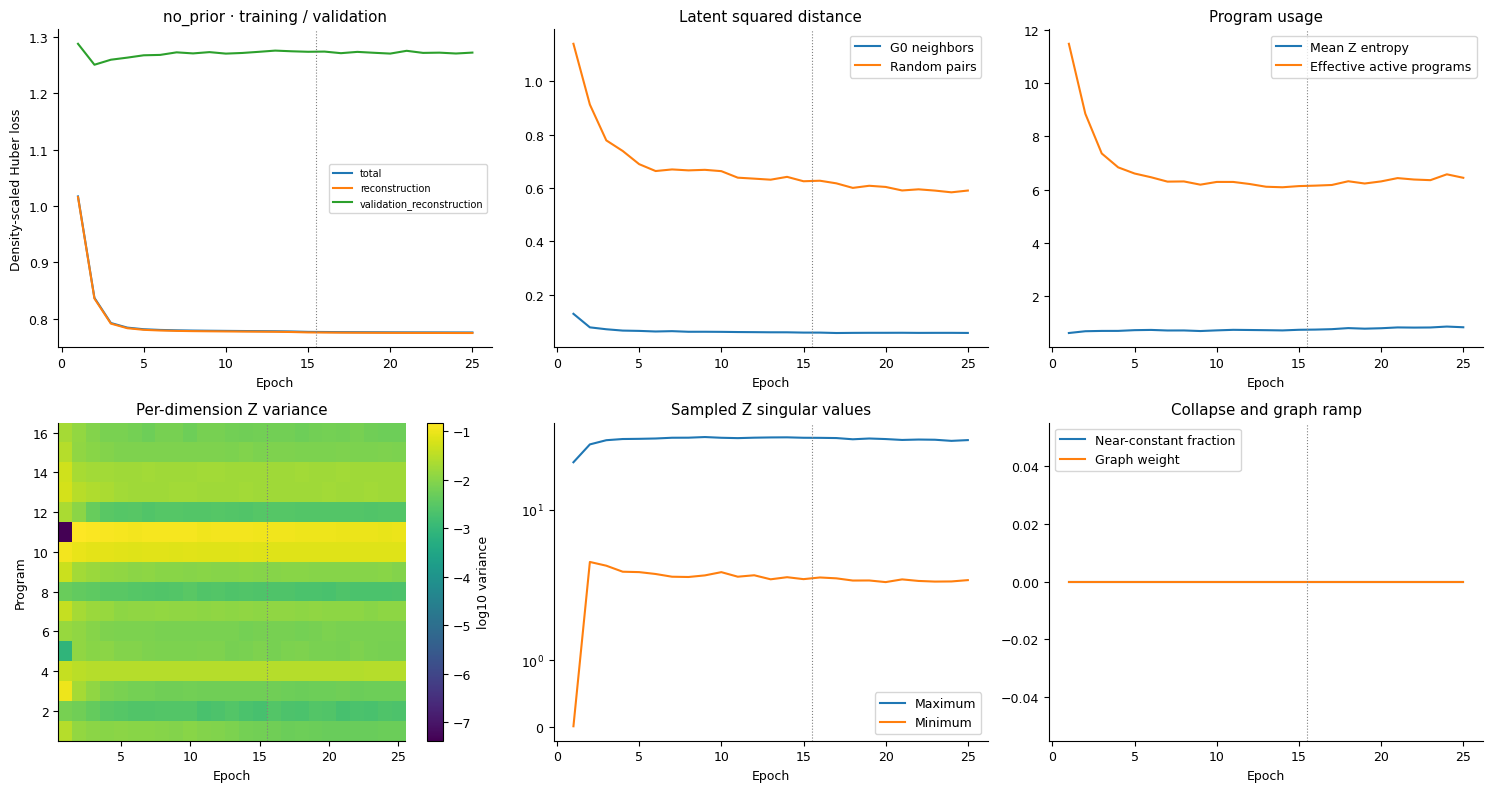

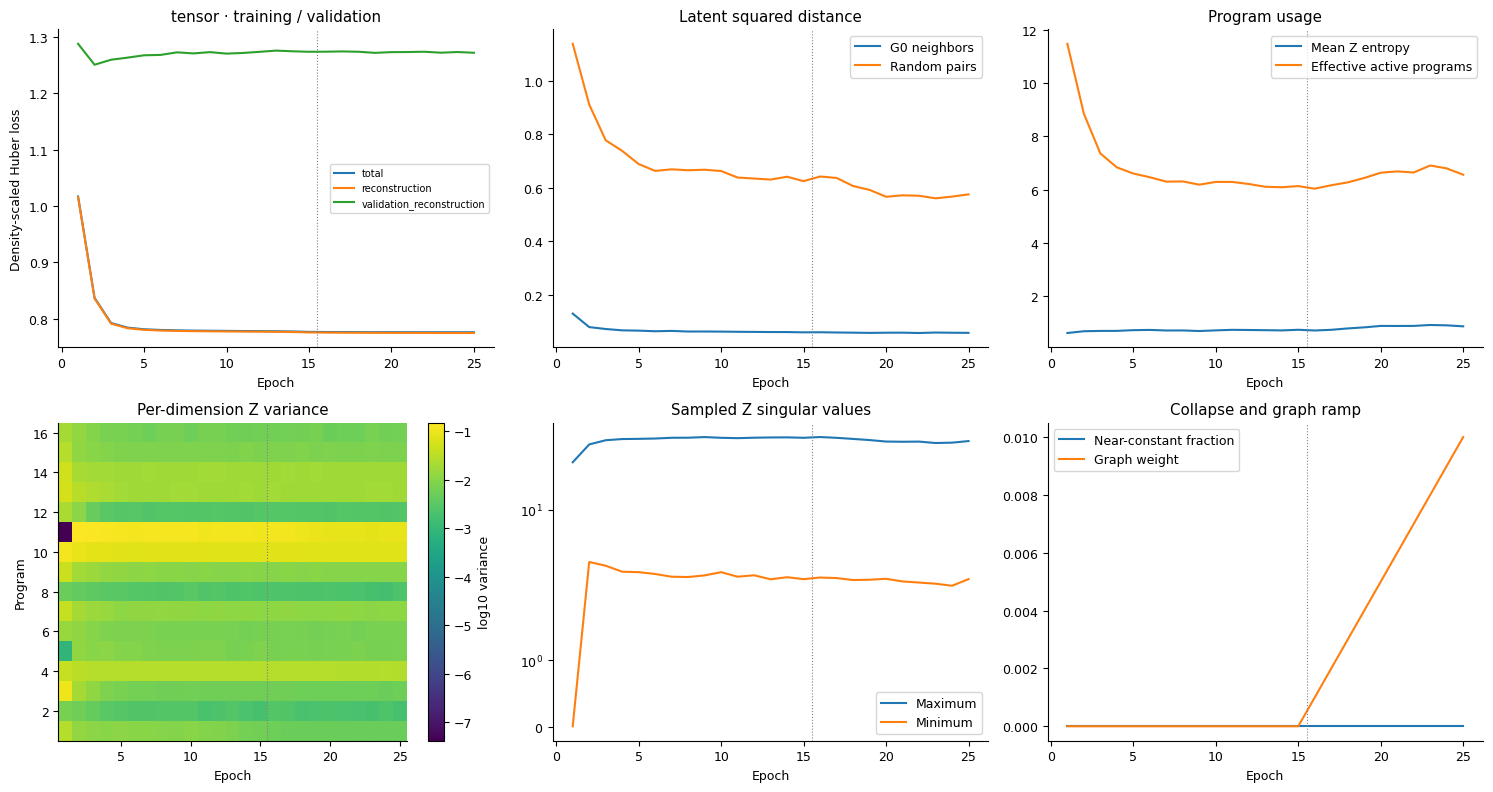

Near-constant means variance < 1e-8 on the fixed 4,096-anchor audit sample. Validation chooses the best checkpoint; separate test entries are never used for early stopping.

In [10]:
report.training('xenium5k')

## 10. Prime 5K historical spatial niches

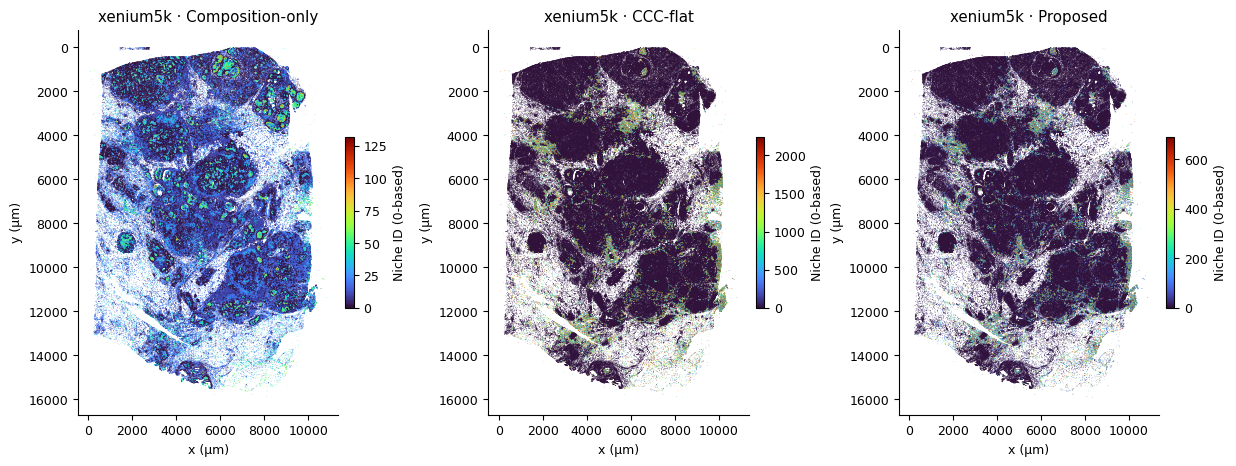

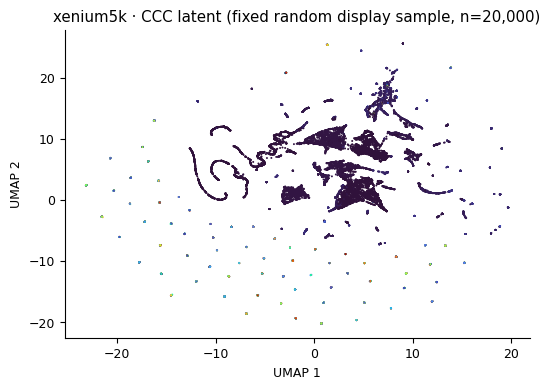

In [11]:
report.spatial('xenium5k')
report.latent_map('xenium5k')

## 11. Prime 5K CCC programs

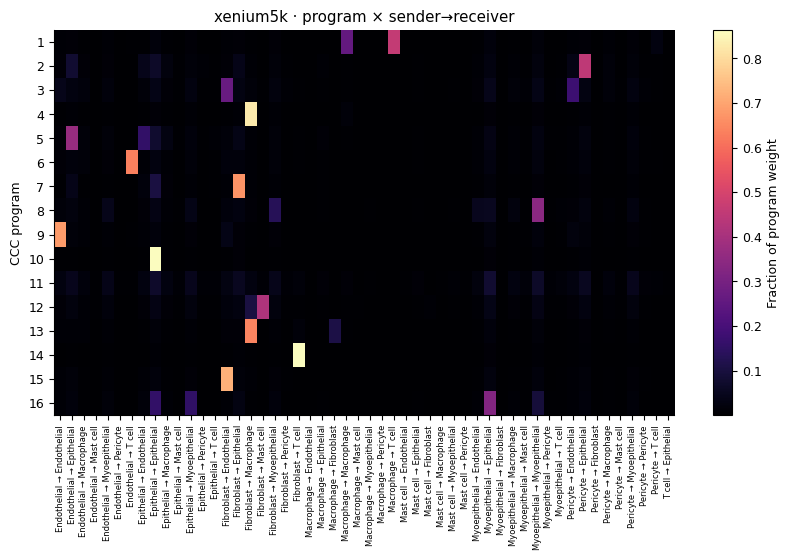

program,entropy,effective_features,fraction_below_1pct_max,weight_sum,top_sender,top_sender_weight,top_receiver,top_receiver_weight,top_pair,top_pair_weight,top_LR,top_LR_weight
1,2.783131,16.169575,0.991903,1.0,Macrophage,0.728247,T cell,0.499831,"('Macrophage', 'T cell')",0.462091,"('PKM', 'CD44')",0.719537
2,4.977890,145.167816,0.528340,1.0,Pericyte,0.526313,Epithelial,0.674374,"('Pericyte', 'Epithelial')",0.448880,"('COL4A1', 'CD44')",0.101316
3,5.166552,175.309341,0.101215,1.0,Fibroblast,0.351955,Endothelial,0.516938,"('Fibroblast', 'Endothelial')",0.269561,"('COL4A1', 'CD93')",0.119163
4,2.127020,8.389829,0.993927,1.0,Fibroblast,0.853039,Macrophage,0.859294,"('Fibroblast', 'Macrophage')",0.827177,"('SERPINE1', 'PLAUR')",0.418699
5,5.113346,166.225555,0.034413,1.0,Endothelial,0.418658,Epithelial,0.554650,"('Endothelial', 'Epithelial')",0.368972,"('COL4A1', 'CD44')",0.072667
6,3.556280,35.032646,0.989879,1.0,Endothelial,0.699350,T cell,0.655779,"('Endothelial', 'T cell')",0.637083,"('COL4A1', 'CD44')",0.317571
7,3.990801,54.098183,0.908907,1.0,Fibroblast,0.697794,Epithelial,0.846604,"('Fibroblast', 'Epithelial')",0.668513,"('TIMP3', 'DDR1')",0.225906
8,5.377852,216.556702,0.026316,1.0,Myoepithelial,0.490532,Myoepithelial,0.593931,"('Myoepithelial', 'Myoepithelial')",0.343265,"('THBS1', 'ITGA3')",0.103582
9,3.414707,30.408051,0.977733,1.0,Endothelial,0.727612,Endothelial,0.757408,"('Endothelial', 'Endothelial')",0.682635,"('APP', 'FLT1')",0.304642
10,3.858586,47.398285,0.929150,1.0,Epithelial,0.883649,Epithelial,0.905210,"('Epithelial', 'Epithelial')",0.863480,"('TIMP3', 'DDR1')",0.175446


program,rank,sender_id,receiver_id,lr_index,sender,receiver,ligand,receptor,lr_id,weight
1,1,4,8,2085,Macrophage,T cell,PKM,CD44,CommuSpace_HS_06177,0.462091
1,2,4,4,2085,Macrophage,Macrophage,PKM,CD44,CommuSpace_HS_06177,0.250426
1,3,7,8,583,Pericyte,T cell,COL4A1,CD44,CommuSpace_HS_01729,0.012108
1,4,7,8,2547,Pericyte,T cell,TIMP3,CD44,CommuSpace_HS_07452,0.008818
1,5,4,4,771,Macrophage,Macrophage,CXCL9,FCGR2A,CommuSpace_HS_02275,0.004416
1,6,7,8,592,Pericyte,T cell,COL4A2,CD44,CommuSpace_HS_01750,0.004034
1,7,4,4,1359,Macrophage,Macrophage,GNAI2,C5AR1,CommuSpace_HS_03953,0.002907
1,8,1,8,583,Endothelial,T cell,COL4A1,CD44,CommuSpace_HS_01729,0.002406
1,9,7,4,583,Pericyte,Macrophage,COL4A1,CD44,CommuSpace_HS_01729,0.001912
1,10,7,4,2547,Pericyte,Macrophage,TIMP3,CD44,CommuSpace_HS_07452,0.001582


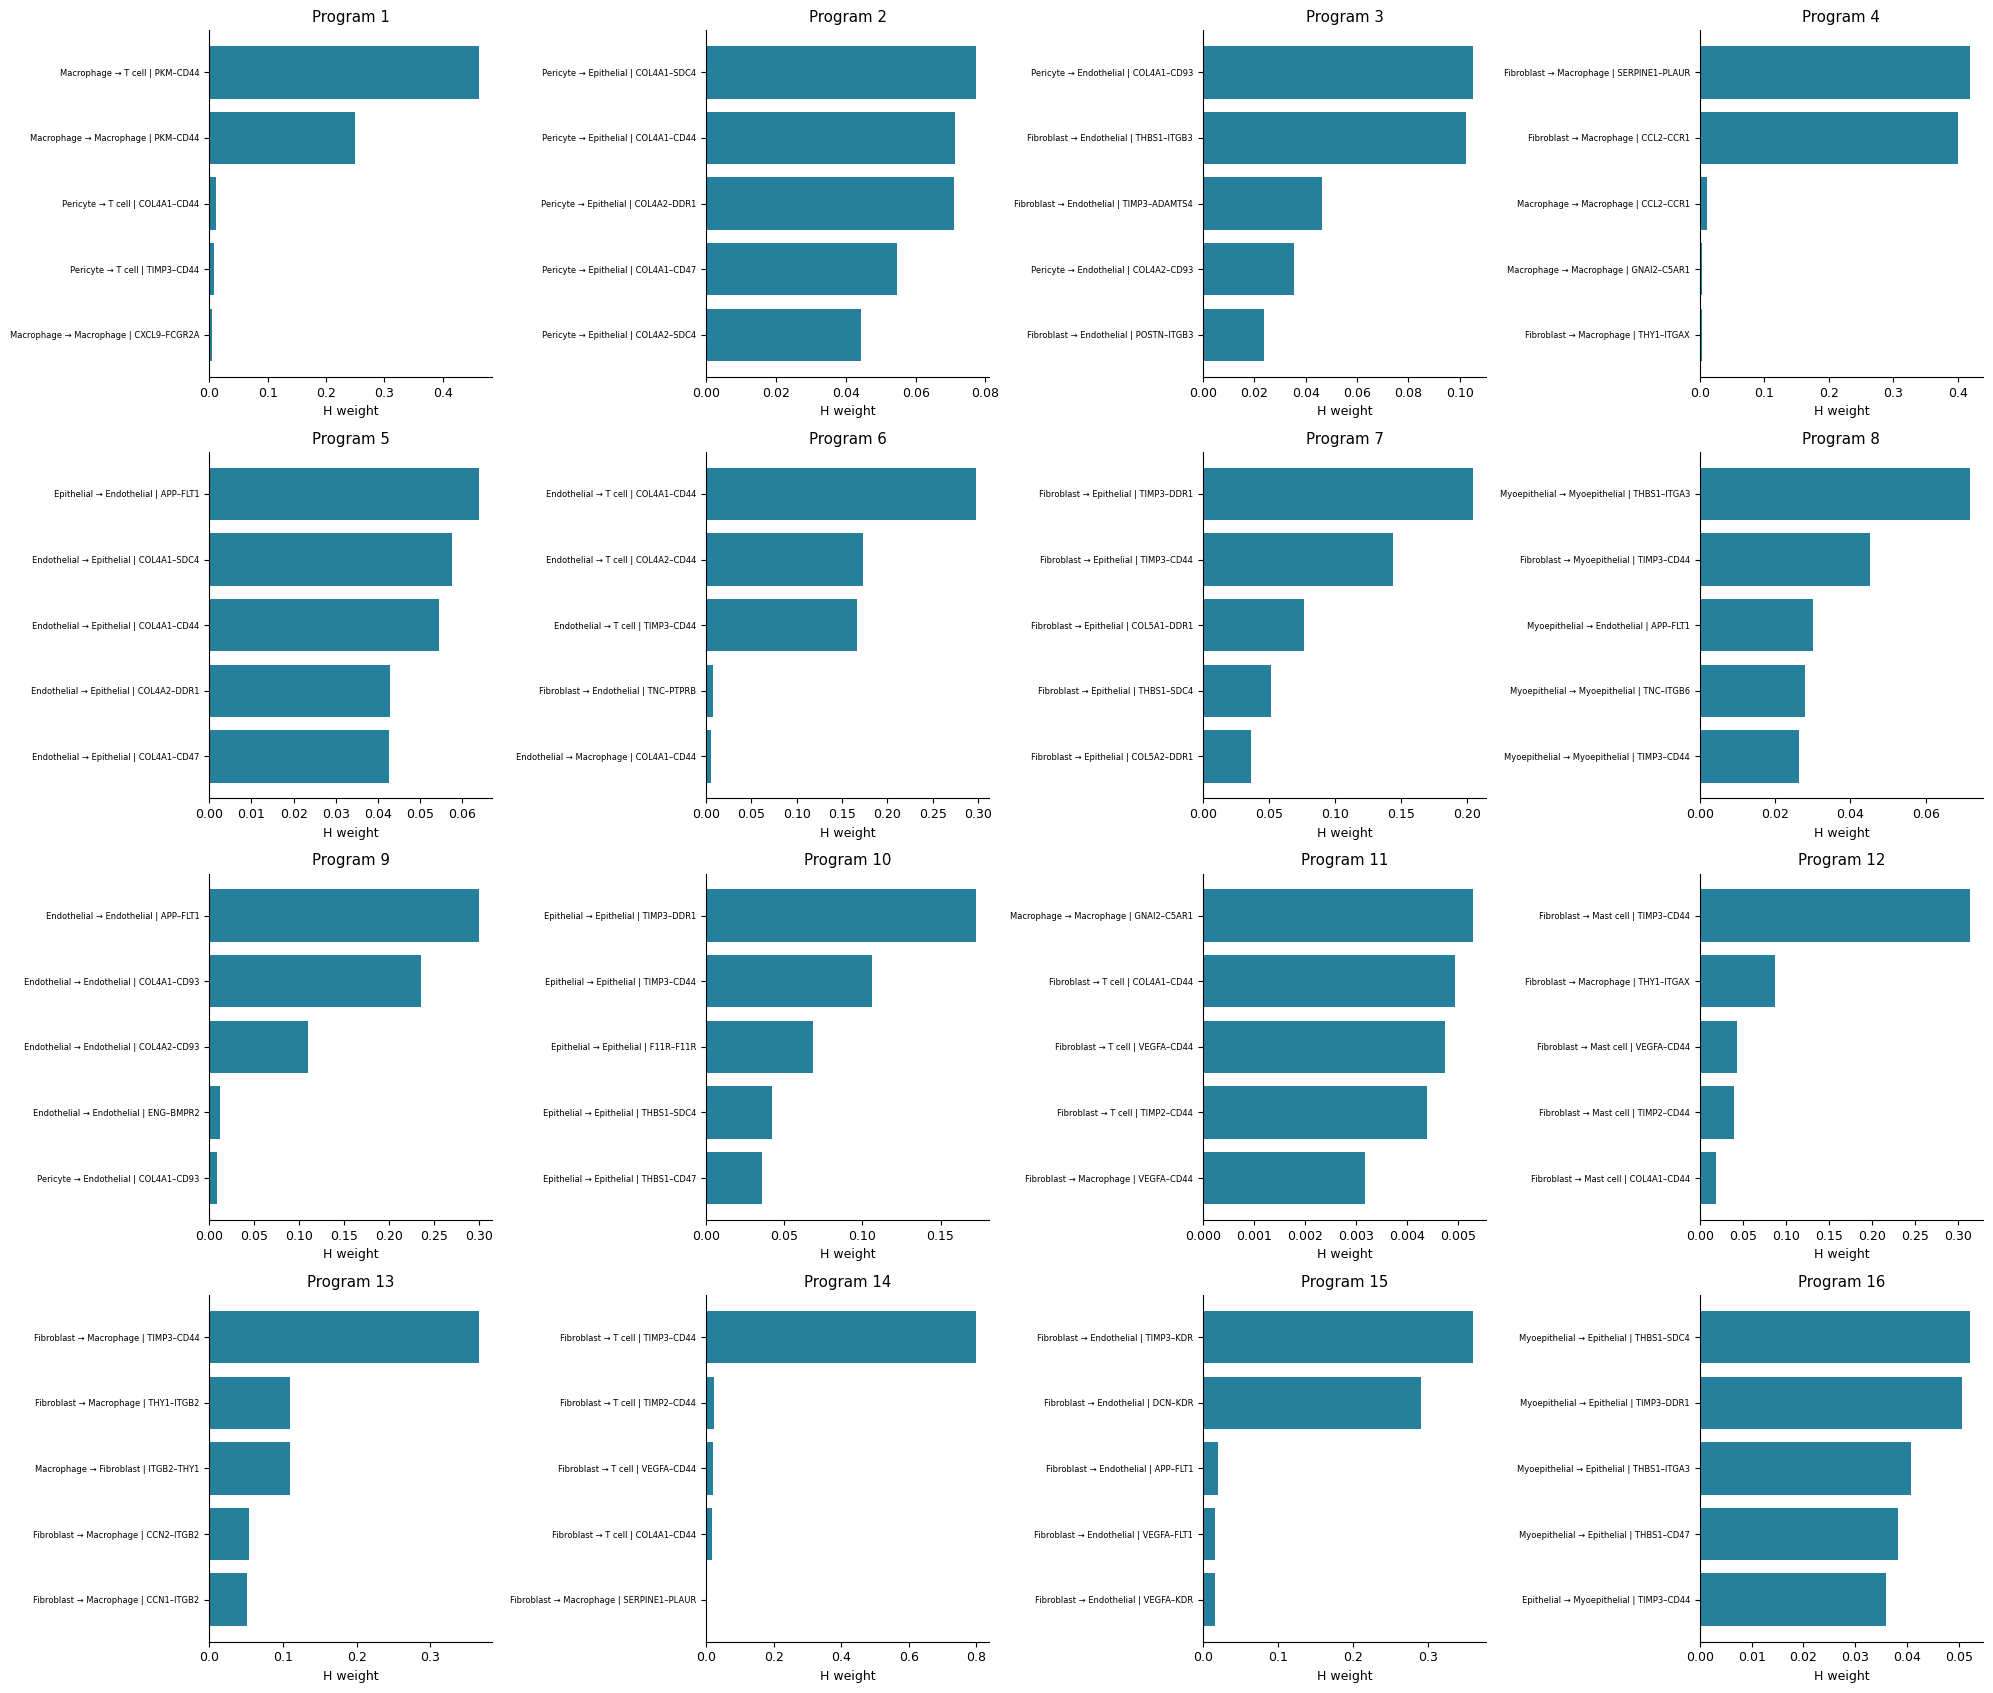

**niche_composition**

niche,B cell,Endothelial,Epithelial,Fibroblast,Macrophage,Mast cell,Myoepithelial,Pericyte,T cell,Unknown
0,0.102863,0.135559,0.003624,0.161350,0.114771,0.015989,0.002758,0.047030,0.256396,0.159659
1,0.011508,0.003168,0.663467,0.008922,0.033590,0.002877,0.001090,0.000617,0.038925,0.235837
2,0.040696,0.073951,0.354853,0.086448,0.096211,0.009400,0.002958,0.024992,0.117300,0.193189
3,0.041478,0.013396,0.378069,0.107727,0.100584,0.010213,0.002378,0.004043,0.130761,0.211350
4,0.123990,0.018961,0.003307,0.155522,0.160035,0.013666,0.001836,0.011537,0.359325,0.151820
5,0.019947,0.069121,0.361808,0.114467,0.068238,0.014022,0.128577,0.024293,0.064465,0.135062
6,0.158364,0.068470,0.002257,0.093514,0.073335,0.013058,0.002037,0.021880,0.438519,0.128568
7,0.126318,0.026252,0.003806,0.177661,0.124845,0.049188,0.002012,0.015754,0.311322,0.162842
8,0.165886,0.008913,0.002181,0.141772,0.049991,0.010930,0.001449,0.004507,0.474577,0.139795
9,0.139127,0.017065,0.004616,0.056638,0.157884,0.017167,0.001579,0.008559,0.406760,0.190604


**niche_program_activity**

niche,Program 1,Program 2,Program 3,Program 4,Program 5,Program 6,Program 7,Program 8,Program 9,Program 10,Program 11,Program 12,Program 13,Program 14,Program 15,Program 16
0,9.886427e-03,4.785524e-04,1.893328e-01,5.459633e-02,4.489314e-03,6.216432e-02,7.831357e-04,1.339930e-03,2.508618e-01,2.043548e-04,2.169970e-01,1.330852e-02,6.429040e-02,0.018503,1.125713e-01,1.212703e-04
1,5.608867e-03,3.607374e-04,3.750133e-05,1.236253e-04,8.146748e-04,5.893403e-05,2.236191e-04,8.977741e-06,1.939323e-06,8.732355e-01,1.189395e-01,8.503690e-05,5.725304e-05,0.000066,6.733685e-06,3.878406e-04
2,2.735246e-03,1.075009e-01,3.764592e-02,1.447009e-02,2.625319e-01,1.961278e-02,1.293500e-01,7.059685e-04,5.205002e-02,1.923501e-01,1.057099e-01,5.450589e-03,2.161553e-02,0.007289,3.911294e-02,1.845311e-03
3,4.927814e-03,2.763654e-03,1.105975e-03,4.010697e-02,3.511631e-03,3.809961e-04,3.951123e-01,2.939682e-04,3.305069e-04,3.052060e-01,1.517266e-01,1.426622e-02,6.025372e-02,0.018405,2.064518e-04,1.401946e-03
4,6.289151e-02,7.079550e-04,2.914073e-03,2.176394e-01,1.667189e-03,1.472782e-03,1.341485e-03,3.285508e-04,4.767979e-04,2.497131e-04,2.005753e-01,4.305975e-03,3.963248e-01,0.108709,2.807288e-04,9.160810e-05
5,1.063835e-03,1.413603e-02,9.160263e-03,6.637220e-03,4.685190e-02,2.057665e-03,4.362136e-02,1.448517e-01,1.336111e-02,1.305796e-01,1.654907e-01,1.784545e-03,5.375360e-03,0.002334,9.696902e-03,4.029844e-01
6,3.185713e-02,2.475777e-04,6.608336e-02,1.071941e-03,5.351573e-03,5.001255e-01,2.776425e-04,4.327339e-04,1.860199e-03,2.402185e-04,3.254909e-01,1.977834e-03,3.041118e-03,0.060968,9.217864e-04,5.193050e-05
7,1.552601e-02,6.432384e-04,6.714447e-03,5.393008e-02,2.776143e-03,6.740604e-03,1.968884e-03,5.050819e-04,7.494861e-04,4.603757e-04,2.781697e-01,5.195210e-01,7.207102e-02,0.039602,5.628396e-04,6.006989e-05
8,6.767500e-04,1.602981e-04,2.024040e-03,5.146836e-04,4.748710e-03,1.753383e-03,3.392769e-04,2.601259e-04,7.754916e-05,1.473621e-04,3.707223e-01,8.827384e-04,1.394491e-03,0.615929,3.495230e-04,3.643531e-05
9,5.579540e-01,1.734427e-03,6.684431e-03,1.196563e-03,3.726254e-03,1.465969e-03,2.288790e-04,1.247260e-04,5.490199e-04,4.829084e-04,4.169400e-01,1.993050e-03,3.231590e-03,0.003332,2.890155e-04,6.857092e-05


**niche_top_edges**

niche,rank,sender_id,receiver_id,lr_index,sender,receiver,ligand,receptor,lr_id,weight
0,1,1,1,131,Endothelial,Endothelial,APP,FLT1,CommuSpace_HS_00391,0.076121
0,2,1,1,585,Endothelial,Endothelial,COL4A1,CD93,CommuSpace_HS_01731,0.059825
0,3,3,1,2549,Fibroblast,Endothelial,TIMP3,KDR,CommuSpace_HS_07454,0.041626
0,4,3,1,785,Fibroblast,Endothelial,DCN,KDR,CommuSpace_HS_02342,0.033888
0,5,1,1,593,Endothelial,Endothelial,COL4A2,CD93,CommuSpace_HS_01751,0.028649
0,6,3,4,2311,Fibroblast,Macrophage,SERPINE1,PLAUR,CommuSpace_HS_06869,0.024749
0,7,3,4,2547,Fibroblast,Macrophage,TIMP3,CD44,CommuSpace_HS_07452,0.024461
0,8,3,4,351,Fibroblast,Macrophage,CCL2,CCR1,CommuSpace_HS_00946,0.022906
0,9,7,1,585,Pericyte,Endothelial,COL4A1,CD93,CommuSpace_HS_01731,0.022580
0,10,3,1,2505,Fibroblast,Endothelial,THBS1,ITGB3,CommuSpace_HS_07380,0.021210


In [12]:
report.programs('xenium5k')

## 12. Baseline comparison

In [13]:
report.baselines()

,dataset,method,n_niches,spatial_agreement,heldout_MAE,heldout_MSE
0,hbc1,CCC-autoencoder-no-prior,63.8,0.378861,0.108668,0.222335
1,hbc1,CCC-flat,37.2,0.468793,0.124273,0.168943
2,hbc1,CCC-tensor,63.8,0.378652,0.108808,0.261893
3,hbc1,Composition-only,174.4,0.357581,NaN,NaN
4,hbc1,Proposed,26.2,0.494085,0.108808,0.261893
5,xenium5k,CCC-autoencoder-no-prior,2456.2,0.252535,0.016581,0.008187
6,xenium5k,CCC-flat,2246.0,0.370903,0.021502,0.007921
7,xenium5k,CCC-tensor,2457.0,0.253363,0.016581,0.008187
8,xenium5k,Composition-only,156.0,0.381304,NaN,NaN
9,xenium5k,Proposed,730.0,0.417649,0.016581,0.008187


Composition-only has no CCC decoder, so reconstruction is NA. Held-out metrics use the same fixed 1,024 anchors and held-out entries, including retained zeros. Spatial agreement is descriptive, not niche accuracy.

## 13. Five-seed stability

ARI                 NMI            \
                              mean       std      mean       std   
method                                                             
CCC-autoencoder-no-prior  0.500400  0.056106  0.707862  0.027109   
CCC-flat                  0.766666  0.041544  0.862298  0.014077   
CCC-tensor                0.526891  0.027636  0.722240  0.019172   
Composition-only          0.351330  0.043854  0.639562  0.039915   
Proposed                  0.560696  0.039432  0.709292  0.021677   

                         program_matched_cosine            
                                           mean       std  
method                                                     
CCC-autoencoder-no-prior               0.800159  0.052693  
CCC-flat                                    NaN       NaN  
CCC-tensor                             0.832748  0.040275  
Composition-only                            NaN       NaN  
Proposed                               0.832748  0.040275

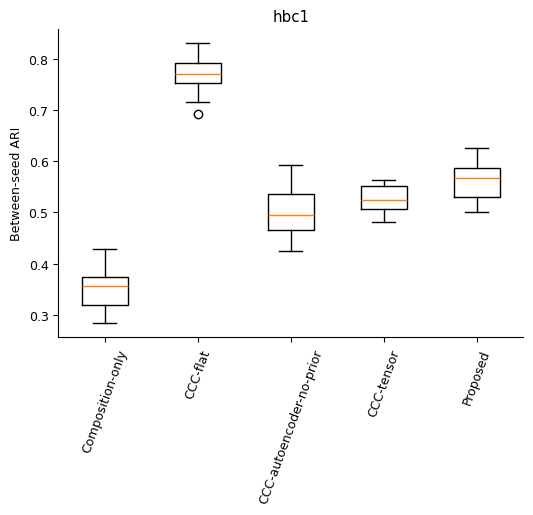

ARI                 NMI            \
                              mean       std      mean       std   
method                                                             
CCC-autoencoder-no-prior  0.460058  0.056270  0.623272  0.014600   
CCC-flat                  0.630582  0.063544  0.875571  0.012660   
CCC-tensor                0.473007  0.043408  0.624229  0.013731   
Composition-only          0.165385  0.033100  0.493350  0.034006   
Proposed                  0.733547  0.029658  0.587559  0.010398   

                         program_matched_cosine            
                                           mean       std  
method                                                     
CCC-autoencoder-no-prior               0.753225  0.043638  
CCC-flat                                    NaN       NaN  
CCC-tensor                             0.753225  0.043638  
Composition-only                            NaN       NaN  
Proposed                               0.753225  0.043638

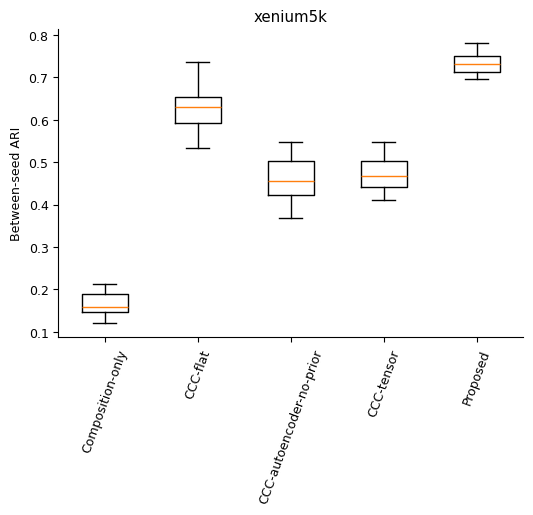

In [14]:
report.stability()

## 14. Historical alpha sensitivity

In [15]:
report.sensitivity()

**hbc1**

alpha,n_niches,median_niche_size,min_niche_size,fraction_cells_niches_lt20,graph_connected_components,mean_degree,degree_min,degree_q25,degree_median,degree_q75,degree_q95,degree_max,spatial_agreement
0.0,65,2039.0,16,0.000096,4,19.761377,12.0,17.0,19.0,22.0,27.0,54.0,0.375283
0.1,35,4050.0,235,0.000000,1,38.515199,23.0,35.0,38.0,41.0,48.0,90.0,0.440570
0.2,29,6220.0,61,0.000000,1,38.515199,23.0,35.0,38.0,41.0,48.0,90.0,0.468673
0.3,22,7271.0,237,0.000000,1,38.515199,23.0,35.0,38.0,41.0,48.0,90.0,0.518916


**xenium5k**

alpha,n_niches,median_niche_size,min_niche_size,fraction_cells_niches_lt20,graph_connected_components,mean_degree,degree_min,degree_q25,degree_median,degree_q75,degree_q95,degree_max,spatial_agreement
0.0,2390,58.0,17,0.000594,2216,21.011437,9.0,16.0,19.0,22.0,34.0,76.0,0.244605
0.1,1719,66.0,31,0.000000,1,39.532068,25.0,35.0,37.0,41.0,55.0,104.0,0.349712
0.2,691,154.0,50,0.000000,1,39.532068,25.0,35.0,37.0,41.0,55.0,104.0,0.421155
0.3,444,233.5,55,0.000000,1,39.532068,25.0,35.0,37.0,41.0,55.0,104.0,0.460980


## 15. Historical within-dataset summary

In [16]:
report.summary()

1. **Latent collapse：** Z/H 尺度自由度已被约束；hbc1: 未见大面积近常数坍缩；各 seed 的近常数维度比例 0.0%–6.2%；xenium5k: 未见大面积近常数坍缩；各 seed 的近常数维度比例 0.0%–0.0%。阈值仅作诊断，不能替代空间与重构评估。

2. **无 prior vs graph prior：** hbc1: CCC-autoencoder-no-prior/CCC-tensor 的 test MSE=0.22234/0.26189，空间一致率=0.379/0.379，seed ARI=0.500/0.527；xenium5k: CCC-autoencoder-no-prior/CCC-tensor 的 test MSE=0.00819/0.00819，空间一致率=0.253/0.253，seed ARI=0.460/0.473。hbc1: 1/5 个 tensor 最佳 checkpoint 来自未加 graph loss 的 warm-up；xenium5k: 5/5 个 tensor 最佳 checkpoint 来自未加 graph loss 的 warm-up。这些 warm-up checkpoint 不能作为 graph prior 有效的证据；不把单个指标当作生物学准确率。

3. **Tensor vs flat：** hbc1: CCC-tensor/CCC-flat 的 test MSE=0.26189/0.16894，空间一致率=0.379/0.469，seed ARI=0.527/0.767；xenium5k: CCC-tensor/CCC-flat 的 test MSE=0.00819/0.00792，空间一致率=0.253/0.371，seed ARI=0.473/0.631。

4. **Composition 弱融合：** hbc1: 弱融合的空间一致率变化 +0.115；ARI 变化 +0.034；xenium5k: 弱融合的空间一致率变化 +0.164；ARI 变化 +0.261。重构与 Z/H 不因图融合改变。

5. **各自结果：** hbc1: Proposed 平均 26.2 个 niche，空间一致率 0.494，test MSE 0.26189；xenium5k: Proposed 平均 730.0 个 niche，空间一致率 0.418，test MSE 0.00819。两个数据不做跨数据集共享验证。

6. **历史碎片化基线：** hbc1: tensor 图平均 1.8 个连通分量，小于20 cells 的 niche 所占细胞比例 0.00%；融合后 0.00%；xenium5k: tensor 图平均 2231.4 个连通分量，小于20 cells 的 niche 所占细胞比例 0.08%；融合后 0.00%。这些是本轮三图融合与 resolution sweep 之前、resolution=1.0 的已保存结果。

7. **失败与限制：** hbc1、xenium5k 的 tensor 在重构和空间一致率上仍不如 CCC-flat，明确记录失败。不继续调参美化结果；所有 NMF 收敛警告与 early-stopping checkpoint 信息保留在训练结果中。

## 16. Seed 40700 · normalized three-graph fusion and resolution selection

### hbc1 · normalized three-graph niche construction

,graph,n_nodes,undirected_edges,directed_edge_mass,edge_mass_per_node,mean_degree,median_degree,mean_weighted_degree
0,G_ccc,166363,1643781,166362.997659,1.0,19.761377,19.0,1.0
1,G_comp,166363,1585485,166362.997267,1.0,19.060548,18.0,1.0
2,G_spatial,166363,1396084,166362.999751,1.0,16.783588,16.0,1.0


**Beta sensitivity at the automatically selected resolution**

,beta,resolution,leiden_objective,modularity,n_niches,median_niche_size,min_niche_size,fraction_cells_niches_lt20,graph_connected_components,mean_degree,degree_min,degree_q25,degree_median,degree_q75,degree_q95,degree_max,spatial_agreement
0,0.00,0.2,183277.876829,0.777607,8,21437.0,1158,0.0,1,38.515199,23.0,35.0,38.0,41.0,48.0,90.0,0.703329
1,0.05,0.2,189370.814024,0.767483,7,26382.0,1139,0.0,1,53.000860,27.0,49.0,52.0,56.0,63.0,106.0,0.721439
2,0.10,0.2,195744.808242,0.753349,7,28304.0,1221,0.0,1,53.000860,27.0,49.0,52.0,56.0,63.0,106.0,0.726507
3,0.20,0.2,208525.276613,0.700405,6,29543.5,1245,0.0,1,53.000860,27.0,49.0,52.0,56.0,63.0,106.0,0.804460


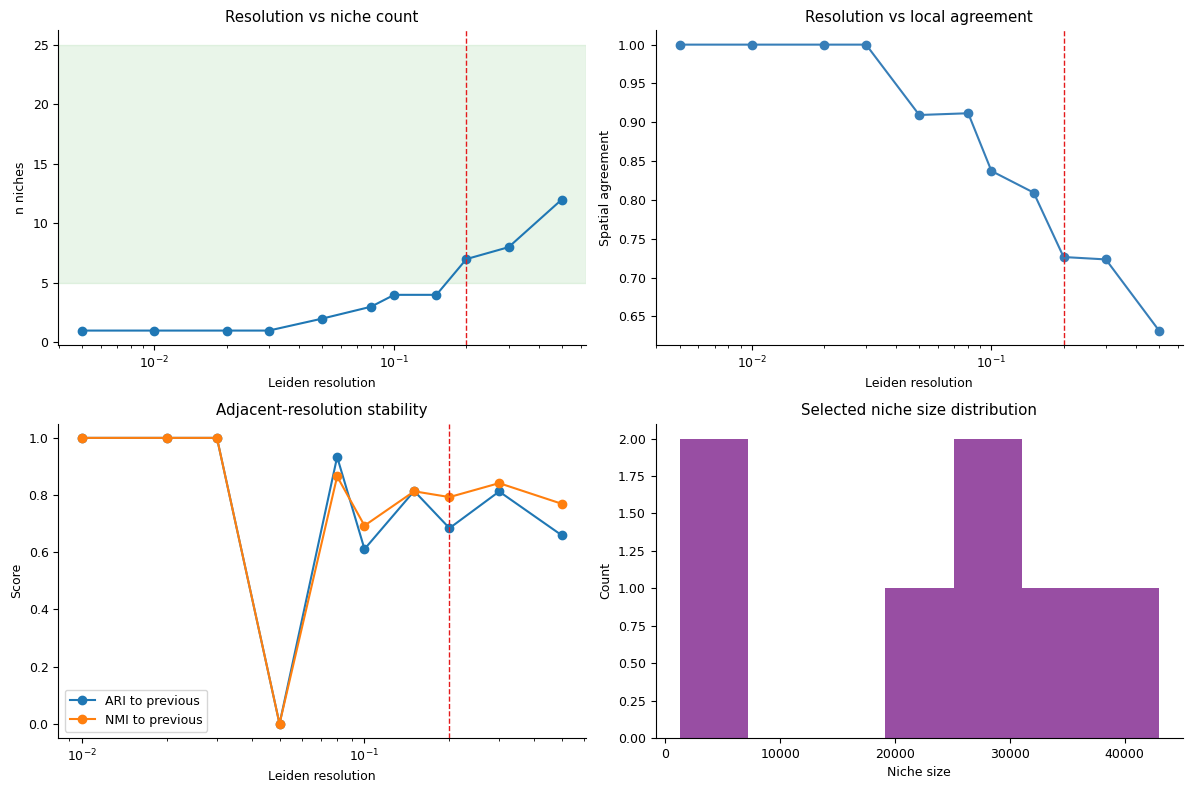

**Selection rule:** No multi-resolution count plateau met the <=25% change rule; used the most stable eligible point. Equal fixed quality terms: stability 0.40, modularity 0.25, spatial agreement 0.25, tiny-niche control 0.10.

,value
dataset,hbc1
seed,40700
alpha,0.2
beta,0.1
selected,True
selection_reason,No multi-resolution count plateau met the <=25...
resolution,0.2
n_niches,7
spatial_agreement,0.726507
median_niche_size,28304.0


**Before vs after graph construction (same seed 40700)**

,result,n_niches,spatial_agreement,median_niche_size,tiny_niche_fraction
0,"Before: CCC + composition, resolution=1",29,0.468673,6220.0,0.0
1,"After: CCC + composition + spatial, selected r...",7,0.726507,28304.0,0.0


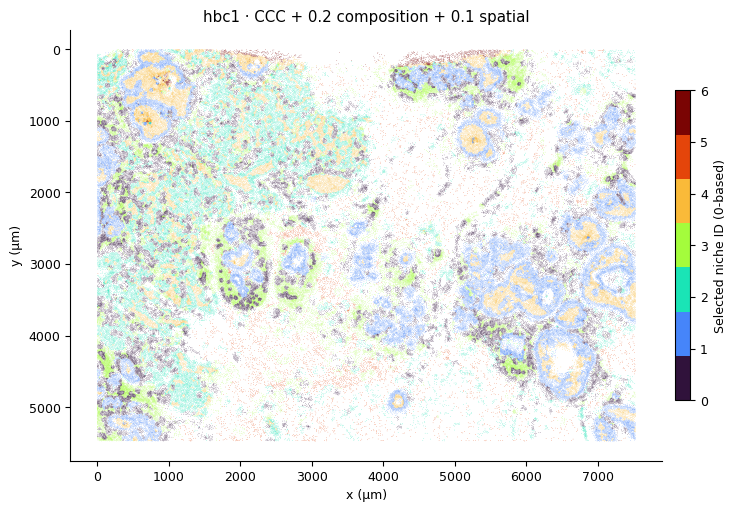

### xenium5k · normalized three-graph niche construction

,graph,n_nodes,undirected_edges,directed_edge_mass,edge_mass_per_node,mean_degree,median_degree,mean_weighted_degree
0,G_ccc,699110,7344653,699109.968866,1.0,21.011437,19.0,1.0
1,G_comp,699110,6506208,699109.982301,1.0,18.612831,18.0,1.0
2,G_spatial,699110,5915558,699109.990606,1.0,16.923111,17.0,1.0


**Beta sensitivity at the automatically selected resolution**

,beta,resolution,leiden_objective,modularity,n_niches,median_niche_size,min_niche_size,fraction_cells_niches_lt20,graph_connected_components,mean_degree,degree_min,degree_q25,degree_median,degree_q75,degree_q95,degree_max,spatial_agreement
0,0.00,0.2,759718.503551,0.769818,85,1670.0,471,0.0,1,39.532062,25.0,35.0,37.0,41.0,55.0,104.0,0.675096
1,0.05,0.2,782577.394172,0.742243,26,3389.0,491,0.0,1,55.125708,30.0,50.0,53.0,57.0,71.0,122.0,0.694012
2,0.10,0.2,808590.617033,0.628684,5,120986.0,68,0.0,1,55.125708,30.0,50.0,53.0,57.0,71.0,122.0,0.827624
3,0.20,0.2,864786.022133,0.614459,3,276584.0,121410,0.0,1,55.125708,30.0,50.0,53.0,57.0,71.0,122.0,0.837544


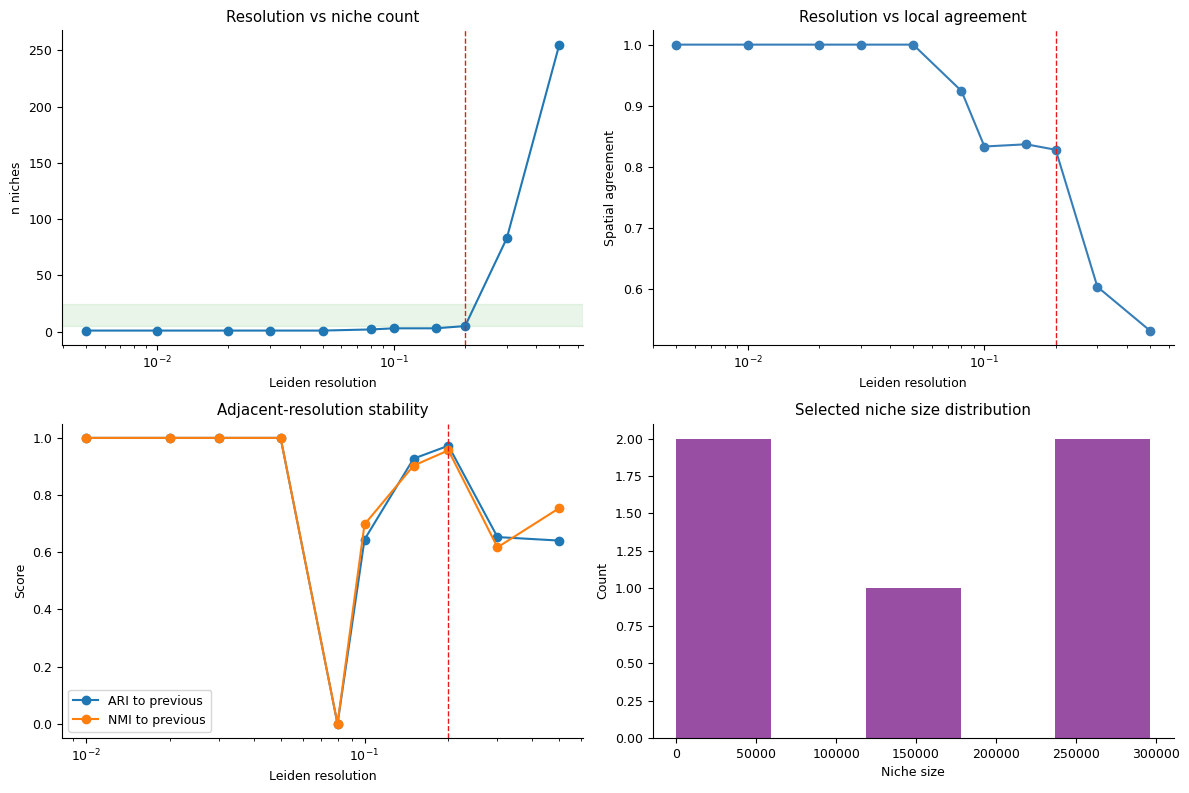

**Selection rule:** No multi-resolution count plateau met the <=25% change rule; used the most stable eligible point. Equal fixed quality terms: stability 0.40, modularity 0.25, spatial agreement 0.25, tiny-niche control 0.10.

,value
dataset,xenium5k
seed,40700
alpha,0.2
beta,0.1
selected,True
selection_reason,No multi-resolution count plateau met the <=25...
resolution,0.2
n_niches,5
spatial_agreement,0.827624
median_niche_size,120986.0


**Before vs after graph construction (same seed 40700)**

,result,n_niches,spatial_agreement,median_niche_size,tiny_niche_fraction
0,"Before: CCC + composition, resolution=1",691,0.421155,154.0,0.0
1,"After: CCC + composition + spatial, selected r...",5,0.827624,120986.0,0.0


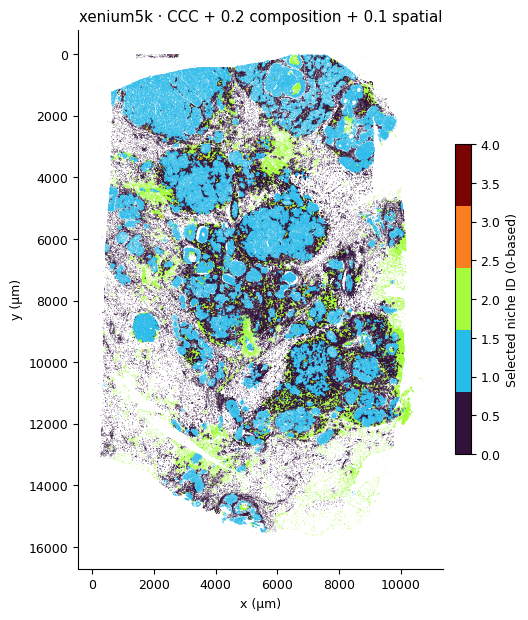

In [17]:
report.graph_selection('hbc1')
report.graph_selection('xenium5k')